In [2]:
# =============================================================================
# COMPREHENSIVE EDA FOR PREDICTIVE MAINTENANCE
# Air Processing Unit (APU) - Multivariate Time-Series Sensor Data
# =============================================================================
# This notebook performs thorough exploratory data analysis on industrial
# sensor data sampled at 0.1Hz (1 sample every 10 seconds) for predictive
# maintenance applications.
# =============================================================================

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Section 1: Data Loading & Overview
This section loads the MetroPT3 Air Compressor dataset and provides an initial overview of its structure, data types, and basic statistics.

In [3]:
# -----------------------------------------------------------------------------
# 1.1 Load Dataset
# -----------------------------------------------------------------------------
file_path = 'dataset/MetroPT3(AirCompressor).csv'

# Load data with timestamp parsing and set as index
df = pd.read_csv(
    file_path,
    parse_dates=['timestamp'],
    index_col='timestamp',
    thousands=',',
    decimal='.'
)

# Drop unnecessary columns (if any unnamed index column exists)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns='Unnamed: 0')

# Sort by timestamp to ensure chronological order
df = df.sort_index()

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

DATASET LOADED SUCCESSFULLY


In [4]:
# -----------------------------------------------------------------------------
# 1.2 Basic Dataset Information
# -----------------------------------------------------------------------------
print("DATASET SHAPE AND STRUCTURE")
print("-" * 60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTime Range:")
print(f"  Start: {df.index.min()}")
print(f"  End:   {df.index.max()}")
print(f"  Duration: {df.index.max() - df.index.min()}")

print("\n" + "=" * 60)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 60)
print(df.dtypes.to_string())

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df.head()

DATASET SHAPE AND STRUCTURE
------------------------------------------------------------
Shape: 1,516,948 rows × 15 columns

Time Range:
  Start: 2020-02-01 00:00:00
  End:   2020-09-01 03:59:50
  Duration: 213 days 03:59:50

COLUMN NAMES AND DATA TYPES
TP2                float64
TP3                float64
H1                 float64
DV_pressure        float64
Reservoirs         float64
Oil_temperature    float64
Motor_current      float64
COMP               float64
DV_eletric         float64
Towers             float64
MPG                float64
LPS                float64
Pressure_switch    float64
Oil_level          float64
Caudal_impulses    float64

FIRST 5 ROWS


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.0120,9.3580,9.3400,-0.0240,9.3580,53.6000,0.0400,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
2020-02-01 00:00:10,-0.0140,9.3480,9.3320,-0.0220,9.3480,53.6750,0.0400,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
2020-02-01 00:00:19,-0.0120,9.3380,9.3220,-0.0220,9.3380,53.6000,0.0425,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
2020-02-01 00:00:29,-0.0120,9.3280,9.3120,-0.0220,9.3280,53.4250,0.0400,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
2020-02-01 00:00:39,-0.0120,9.3180,9.3020,-0.0220,9.3180,53.4750,0.0400,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000


In [5]:
# -----------------------------------------------------------------------------
# 1.3 Descriptive Statistics
# -----------------------------------------------------------------------------
print("DESCRIPTIVE STATISTICS FOR ALL SENSORS")
print("=" * 60)
df.describe().transpose()

DESCRIPTIVE STATISTICS FOR ALL SENSORS


,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0000,1.3678,3.2509,-0.0320,-0.0140,-0.0120,-0.0100,10.6760
TP3,1516948.0000,8.9846,0.6391,0.7300,8.4920,8.9600,9.4920,10.3020
H1,1516948.0000,7.5682,3.3332,-0.0360,8.2540,8.7840,9.3740,10.2880
DV_pressure,1516948.0000,0.0560,0.3824,-0.0320,-0.0220,-0.0200,-0.0180,9.8440
Reservoirs,1516948.0000,8.9852,0.6383,0.7120,8.4940,8.9600,9.4920,10.3000
Oil_temperature,1516948.0000,62.6442,6.5163,15.4000,57.7750,62.7000,67.2500,89.0500
Motor_current,1516948.0000,2.0502,2.3021,0.0200,0.0400,0.0450,3.8075,9.2950
COMP,1516948.0000,0.8370,0.3694,0.0000,1.0000,1.0000,1.0000,1.0000
DV_eletric,1516948.0000,0.1606,0.3672,0.0000,0.0000,0.0000,0.0000,1.0000
Towers,1516948.0000,0.9198,0.2715,0.0000,1.0000,1.0000,1.0000,1.0000


In [6]:
# -----------------------------------------------------------------------------
# 1.4 Missing Values Check
# -----------------------------------------------------------------------------
print("MISSING VALUES ANALYSIS")
print("=" * 60)
missing_counts = df.isna().sum()
missing_pct = (df.isna().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df.to_string())
print(f"\nTotal cells with missing values: {df.isna().sum().sum()}")
print(f"Duplicate timestamps: {df.index.duplicated().sum()}")

MISSING VALUES ANALYSIS
                 Missing Count  Missing %
TP2                          0     0.0000
TP3                          0     0.0000
H1                           0     0.0000
DV_pressure                  0     0.0000
Reservoirs                   0     0.0000
Oil_temperature              0     0.0000
Motor_current                0     0.0000
COMP                         0     0.0000
DV_eletric                   0     0.0000
Towers                       0     0.0000
MPG                          0     0.0000
LPS                          0     0.0000
Pressure_switch              0     0.0000
Oil_level                    0     0.0000
Caudal_impulses              0     0.0000

Total cells with missing values: 0
Duplicate timestamps: 0


# Section 2: Data Sanity Checks (Time Consistency)
Verify the sampling rate, detect missing timestamps, and analyze timestamp gaps in the time series data.

In [7]:
# -----------------------------------------------------------------------------
# 2.1 Sampling Rate Analysis
# -----------------------------------------------------------------------------
# Calculate time differences between consecutive samples
time_diffs = df.index.to_series().diff().dropna()

print("SAMPLING RATE ANALYSIS")
print("=" * 60)
print(f"Expected sampling rate: 0.1Hz (1 sample every 10 seconds)")
print(f"\nActual time differences statistics:")
print(f"  Mean interval:   {time_diffs.mean()}")
print(f"  Median interval: {time_diffs.median()}")
print(f"  Min interval:    {time_diffs.min()}")
print(f"  Max interval:    {time_diffs.max()}")
print(f"  Std deviation:   {time_diffs.std()}")

# Count samples by interval duration
interval_counts = time_diffs.value_counts().head(10)
print("\nMost common time intervals:")
print(interval_counts.to_string())

SAMPLING RATE ANALYSIS
Expected sampling rate: 0.1Hz (1 sample every 10 seconds)

Actual time differences statistics:
  Mean interval:   0 days 00:00:12.141221
  Median interval: 0 days 00:00:10
  Min interval:    0 days 00:00:08
  Max interval:    2 days 00:01:58
  Std deviation:   0 days 00:05:14.107266

Most common time intervals:
timestamp
0 days 00:00:10    1337521
0 days 00:00:09     128277
0 days 00:00:12      38321
0 days 00:00:13       7988
0 days 00:00:11       4471
0 days 00:00:21         10
0 days 00:00:19          5
0 days 00:00:22          4
0 days 00:00:20          3
0 days 00:00:17          3


In [8]:
# -----------------------------------------------------------------------------
# 2.2 Missing Timestamps & Gaps Detection
# -----------------------------------------------------------------------------
# Define threshold for gap detection (anything > 10 seconds is a gap for 0.1Hz data)
gap_threshold = pd.Timedelta('10s')

# Identify gaps
gaps = time_diffs[time_diffs > gap_threshold]
total_intervals = len(time_diffs)
irregular_intervals = len(gaps)

print("TIMESTAMP GAPS ANALYSIS")
print("=" * 60)
print(f"Total intervals analyzed: {total_intervals:,}")
print(f"Irregular intervals (> 10s): {irregular_intervals:,}")
print(f"Percentage of gaps: {(irregular_intervals/total_intervals)*100:.4f}%")

if len(gaps) > 0:
    print(f"\nGap Statistics:")
    print(f"  Largest gap:  {gaps.max()}")
    print(f"  Smallest gap: {gaps.min()}")
    print(f"  Average gap:  {gaps.mean()}")
    print(f"  Total gap duration: {gaps.sum()}")
    
    # Calculate expected vs actual data points
    expected_duration = df.index.max() - df.index.min()
    expected_points = expected_duration.total_seconds() / 10  # 0.1Hz = 1 sample per 10 seconds
    actual_points = len(df)
    missing_points = expected_points - actual_points
    
    print(f"\nExpected data points (at 0.1Hz): {int(expected_points):,}")
    print(f"Actual data points: {actual_points:,}")
    print(f"Estimated missing points: {int(missing_points):,} ({(missing_points/expected_points)*100:.2f}%)")

TIMESTAMP GAPS ANALYSIS
Total intervals analyzed: 1,516,947
Irregular intervals (> 10s): 51,147
Percentage of gaps: 3.3717%

Gap Statistics:
  Largest gap:  2 days 00:01:58
  Smallest gap: 0 days 00:00:11
  Average gap:  0 days 00:01:16.013666
  Total gap duration: 44 days 23:57:51

Expected data points (at 0.1Hz): 1,841,759
Actual data points: 1,516,948
Estimated missing points: 324,811 (17.64%)


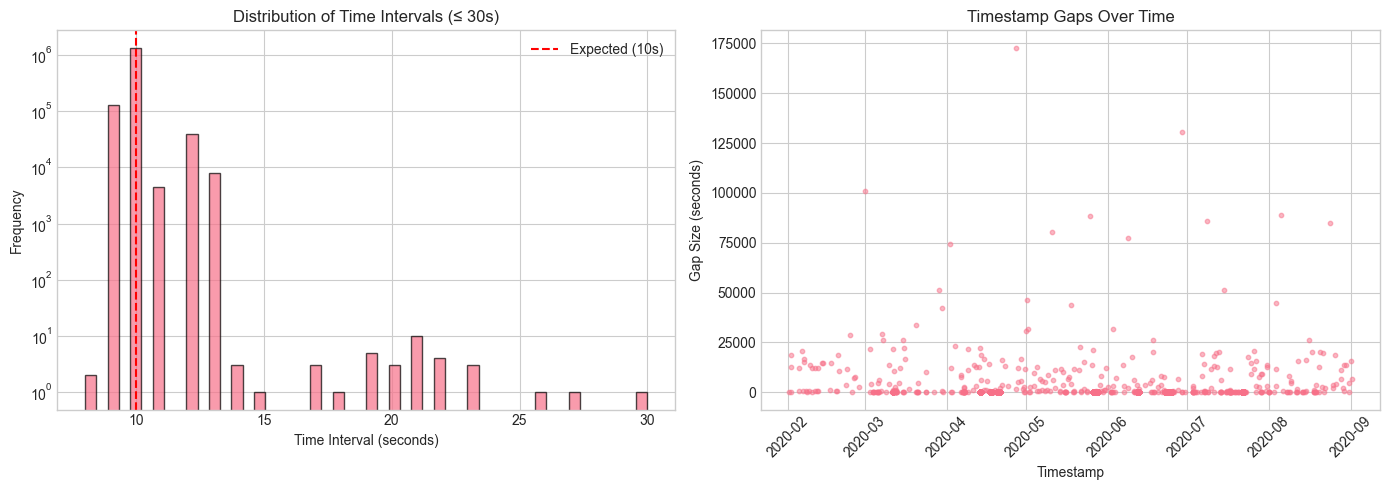


✓ Time consistency analysis complete


In [9]:
# -----------------------------------------------------------------------------
# 2.3 Visualize Gap Distribution
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of all time intervals
ax1 = axes[0]
time_diffs_seconds = time_diffs.dt.total_seconds()
ax1.hist(time_diffs_seconds[time_diffs_seconds <= 30], bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(x=10, color='r', linestyle='--', label='Expected (10s)')
ax1.set_xlabel('Time Interval (seconds)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Time Intervals (≤ 30s)')
ax1.legend()
ax1.set_yscale('log')

# Plot 2: Gap sizes over time
ax2 = axes[1]
if len(gaps) > 0:
    gap_seconds = gaps.dt.total_seconds()
    ax2.scatter(gaps.index, gap_seconds, alpha=0.5, s=10)
    ax2.set_xlabel('Timestamp')
    ax2.set_ylabel('Gap Size (seconds)')
    ax2.set_title('Timestamp Gaps Over Time')
    ax2.tick_params(axis='x', rotation=45)
else:
    ax2.text(0.5, 0.5, 'No significant gaps detected', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Timestamp Gaps Over Time')

plt.tight_layout()
plt.show()

print("\n✓ Time consistency analysis complete")

# Section 3: Signal Visualization & Structure
Plot raw time series, rolling statistics, and seasonal decomposition for key sensors.

In [10]:
# -----------------------------------------------------------------------------
# 3.1 Define Key Sensors for Analysis
# -----------------------------------------------------------------------------
# Select key sensors based on domain knowledge for APU systems
# These typically include pressure, temperature, and motor-related measurements

# List all available columns
print("AVAILABLE SENSORS IN DATASET")
print("=" * 60)
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

# Define key sensors for detailed analysis
# Adjust these based on actual column names in your dataset
key_sensors = ['TP2', 'TP3', 'Motor_current', 'Oil_temperature']

# Verify sensors exist in dataset
available_key_sensors = [s for s in key_sensors if s in df.columns]
print(f"\nKey sensors selected for analysis: {available_key_sensors}")

if len(available_key_sensors) < len(key_sensors):
    missing = set(key_sensors) - set(available_key_sensors)
    print(f"Warning: Sensors not found: {missing}")

AVAILABLE SENSORS IN DATASET
   1. TP2
   2. TP3
   3. H1
   4. DV_pressure
   5. Reservoirs
   6. Oil_temperature
   7. Motor_current
   8. COMP
   9. DV_eletric
  10. Towers
  11. MPG
  12. LPS
  13. Pressure_switch
  14. Oil_level
  15. Caudal_impulses

Key sensors selected for analysis: ['TP2', 'TP3', 'Motor_current', 'Oil_temperature']


RAW TIME SERIES PLOTS


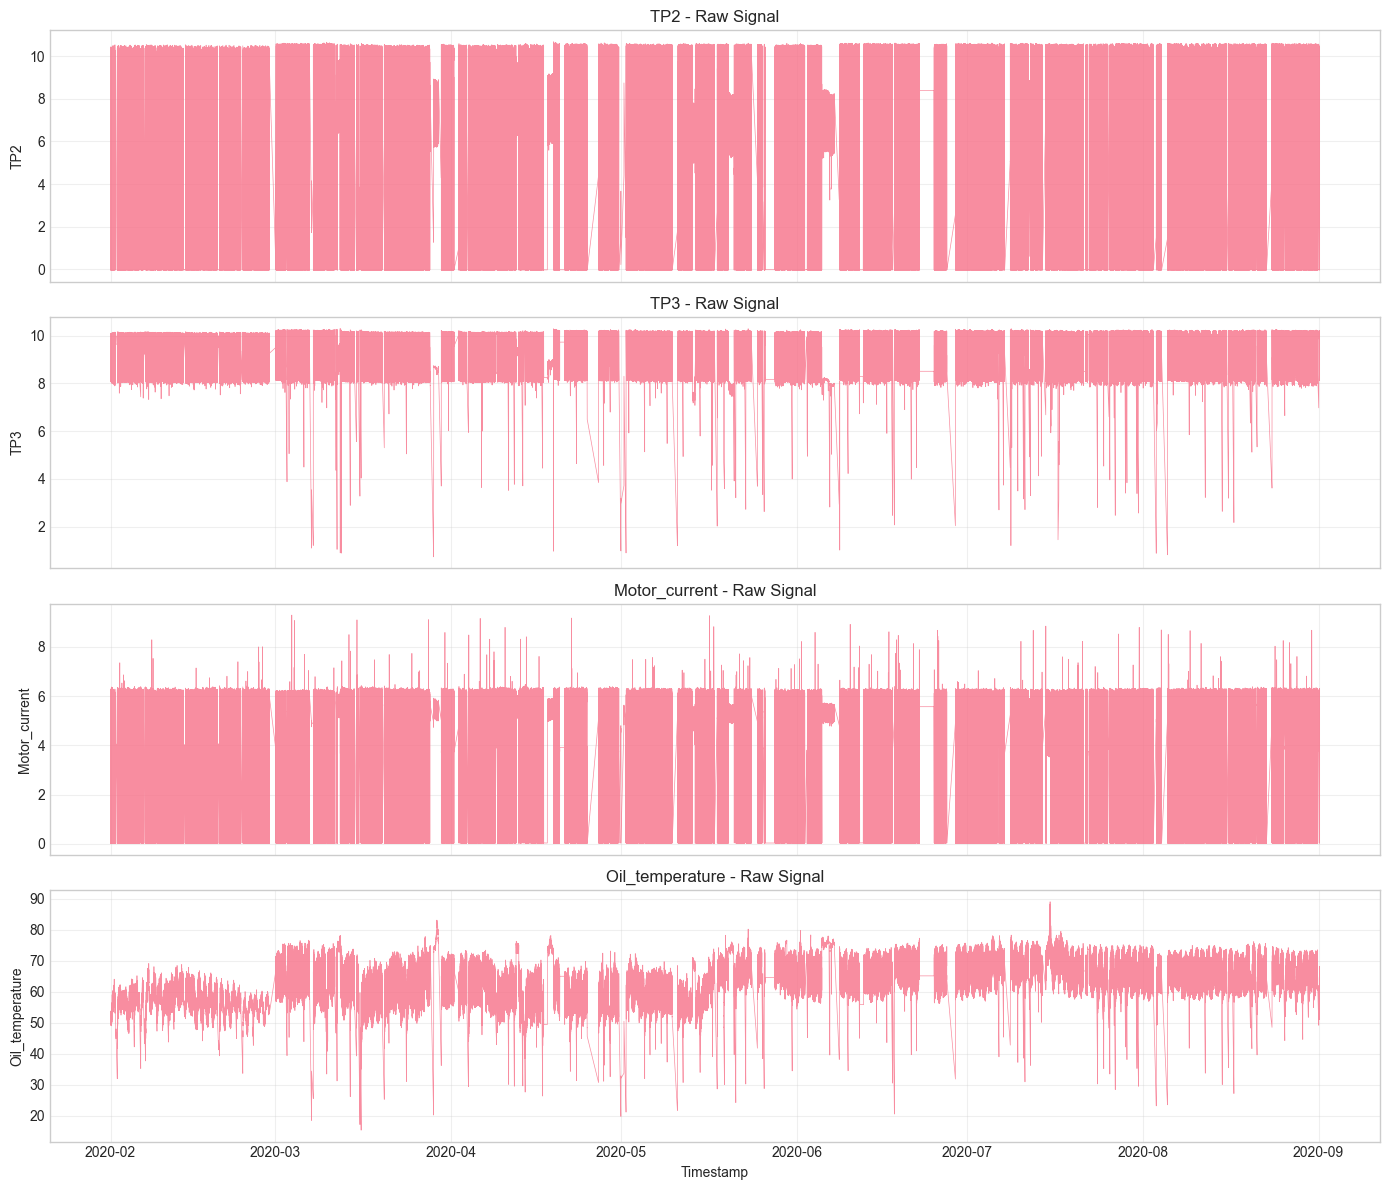

In [11]:
# -----------------------------------------------------------------------------
# 3.2 Raw Time Series Visualization
# -----------------------------------------------------------------------------
def plot_raw_timeseries(data, sensors, title_prefix=""):
    """Plot raw time series for multiple sensors."""
    n_sensors = len(sensors)
    fig, axes = plt.subplots(n_sensors, 1, figsize=(14, 3*n_sensors), sharex=True)
    
    if n_sensors == 1:
        axes = [axes]
    
    for ax, sensor in zip(axes, sensors):
        ax.plot(data.index, data[sensor], linewidth=0.5, alpha=0.8)
        ax.set_ylabel(sensor)
        ax.set_title(f'{title_prefix}{sensor} - Raw Signal')
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Timestamp')
    plt.tight_layout()
    plt.show()

print("RAW TIME SERIES PLOTS")
print("=" * 60)
plot_raw_timeseries(df, available_key_sensors)

ROLLING STATISTICS ANALYSIS
Window size: 360 samples (1 hour at 0.1Hz)



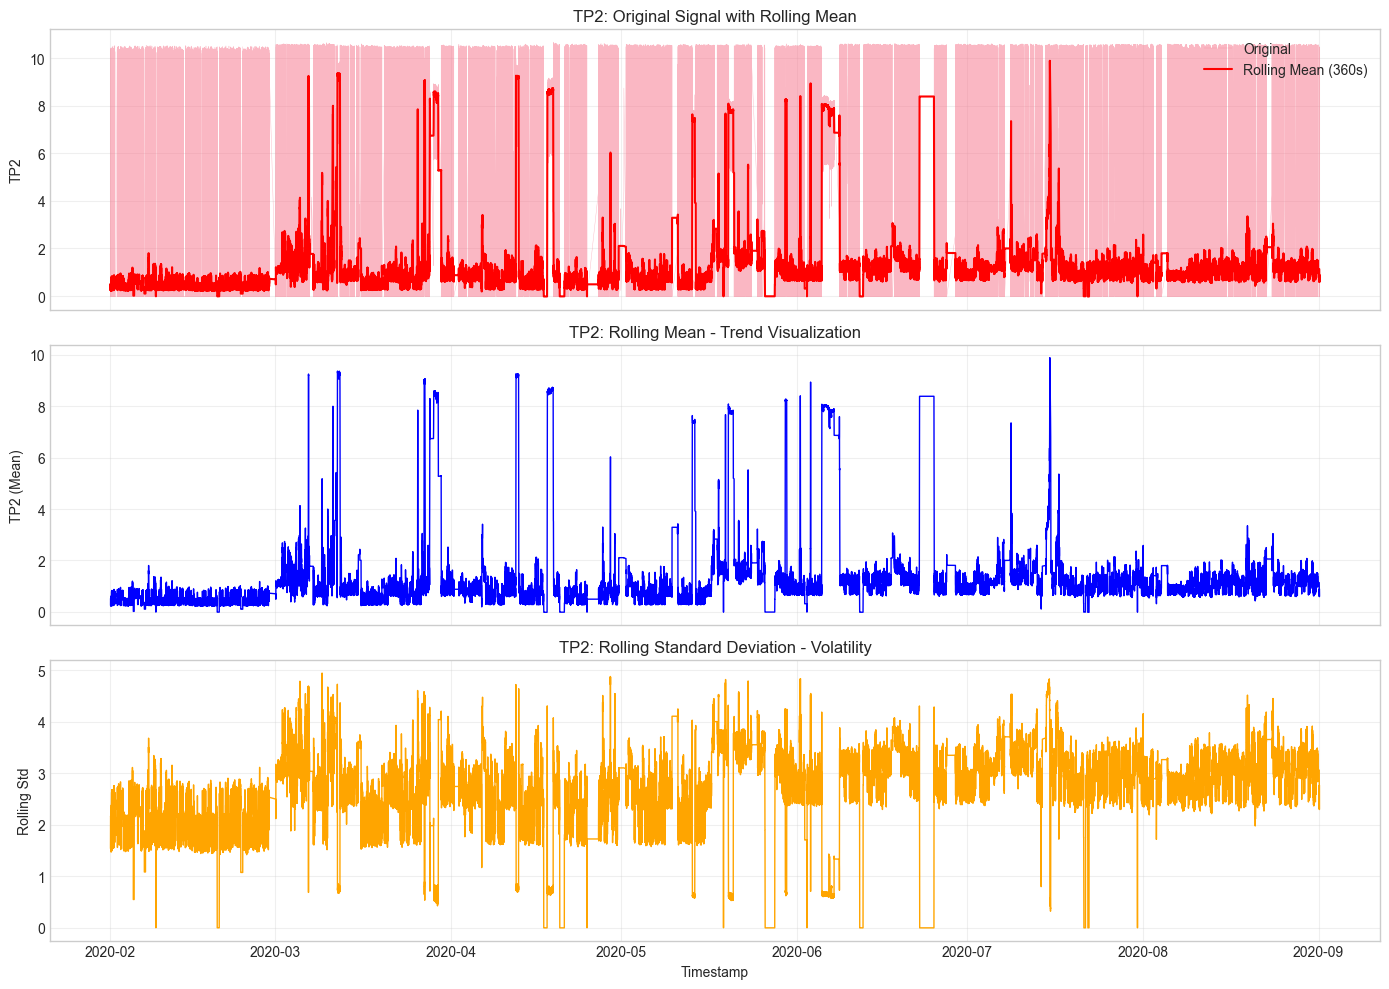

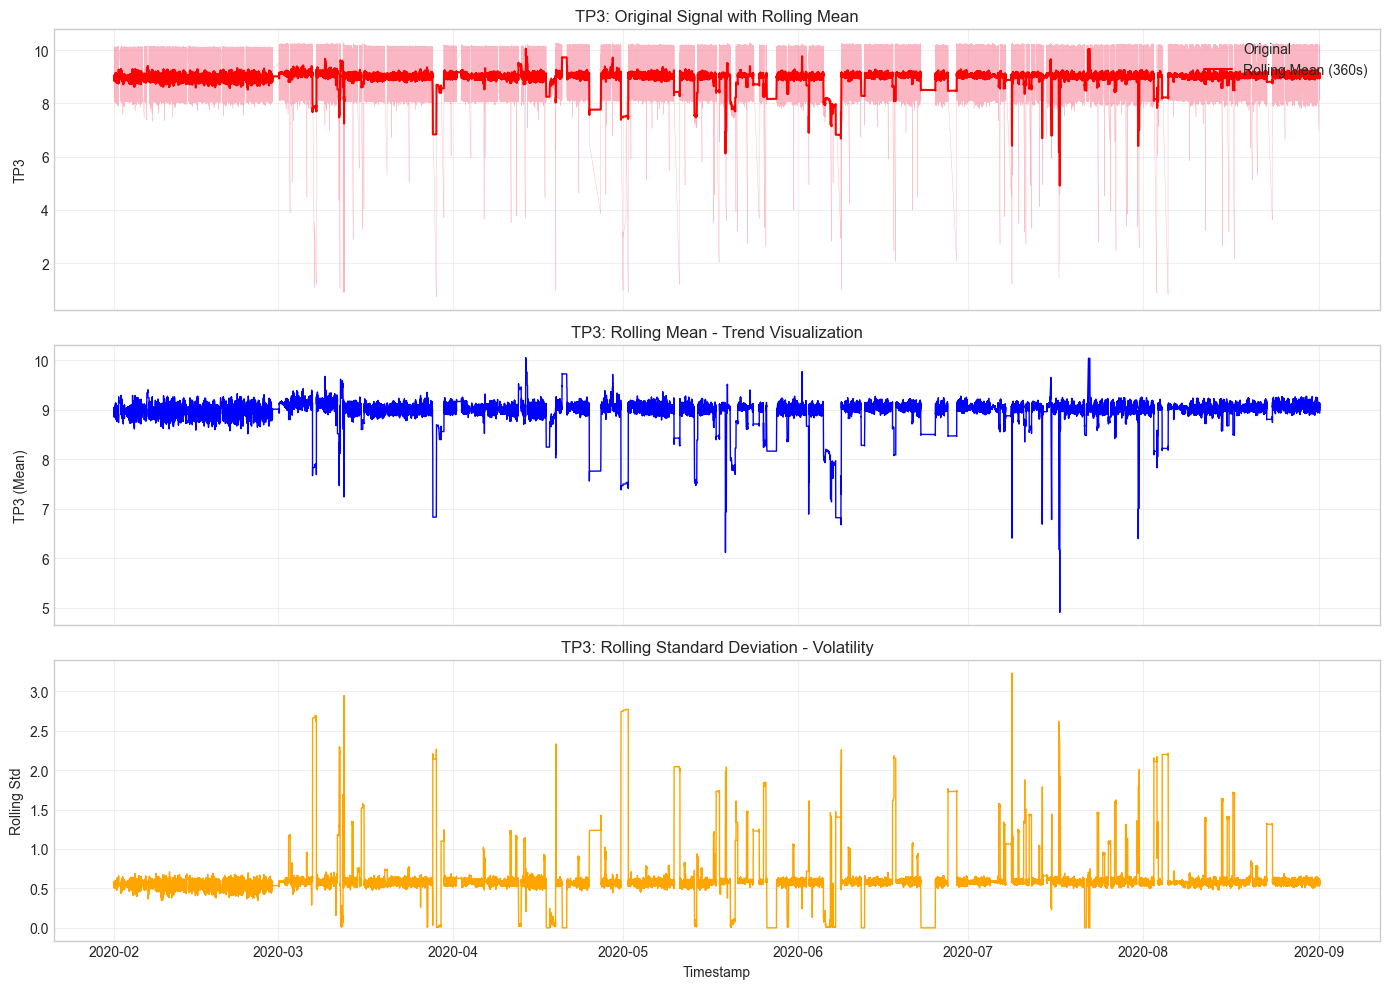

In [12]:
# -----------------------------------------------------------------------------
# 3.3 Rolling Statistics (Trend & Cycles Detection)
# -----------------------------------------------------------------------------
def plot_rolling_statistics(data, sensor, window_size=360):
    """
    Plot rolling mean and rolling std to reveal trends and volatility patterns.
    Default window: 360 samples = 1 hour at 0.1Hz sampling rate (10s per sample)
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    series = data[sensor]
    rolling_mean = series.rolling(window=window_size, center=True).mean()
    rolling_std = series.rolling(window=window_size, center=True).std()
    
    # Original signal
    axes[0].plot(data.index, series, linewidth=0.3, alpha=0.5, label='Original')
    axes[0].plot(data.index, rolling_mean, color='red', linewidth=1.5, label=f'Rolling Mean ({window_size}s)')
    axes[0].set_ylabel(sensor)
    axes[0].set_title(f'{sensor}: Original Signal with Rolling Mean')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Rolling mean only (trend visualization)
    axes[1].plot(data.index, rolling_mean, color='blue', linewidth=1)
    axes[1].set_ylabel(f'{sensor} (Mean)')
    axes[1].set_title(f'{sensor}: Rolling Mean - Trend Visualization')
    axes[1].grid(True, alpha=0.3)
    
    # Rolling std (volatility)
    axes[2].plot(data.index, rolling_std, color='orange', linewidth=1)
    axes[2].set_ylabel('Rolling Std')
    axes[2].set_title(f'{sensor}: Rolling Standard Deviation - Volatility')
    axes[2].set_xlabel('Timestamp')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot rolling statistics for key sensors
print("ROLLING STATISTICS ANALYSIS")
print("=" * 60)
print("Window size: 360 samples (1 hour at 0.1Hz)\n")

for sensor in available_key_sensors[:2]:  # Limit to first 2 for brevity
    plot_rolling_statistics(df, sensor, window_size=360)

SEASONAL DECOMPOSITION
Using 1-hour period (360 samples at 0.1Hz) as base cycle



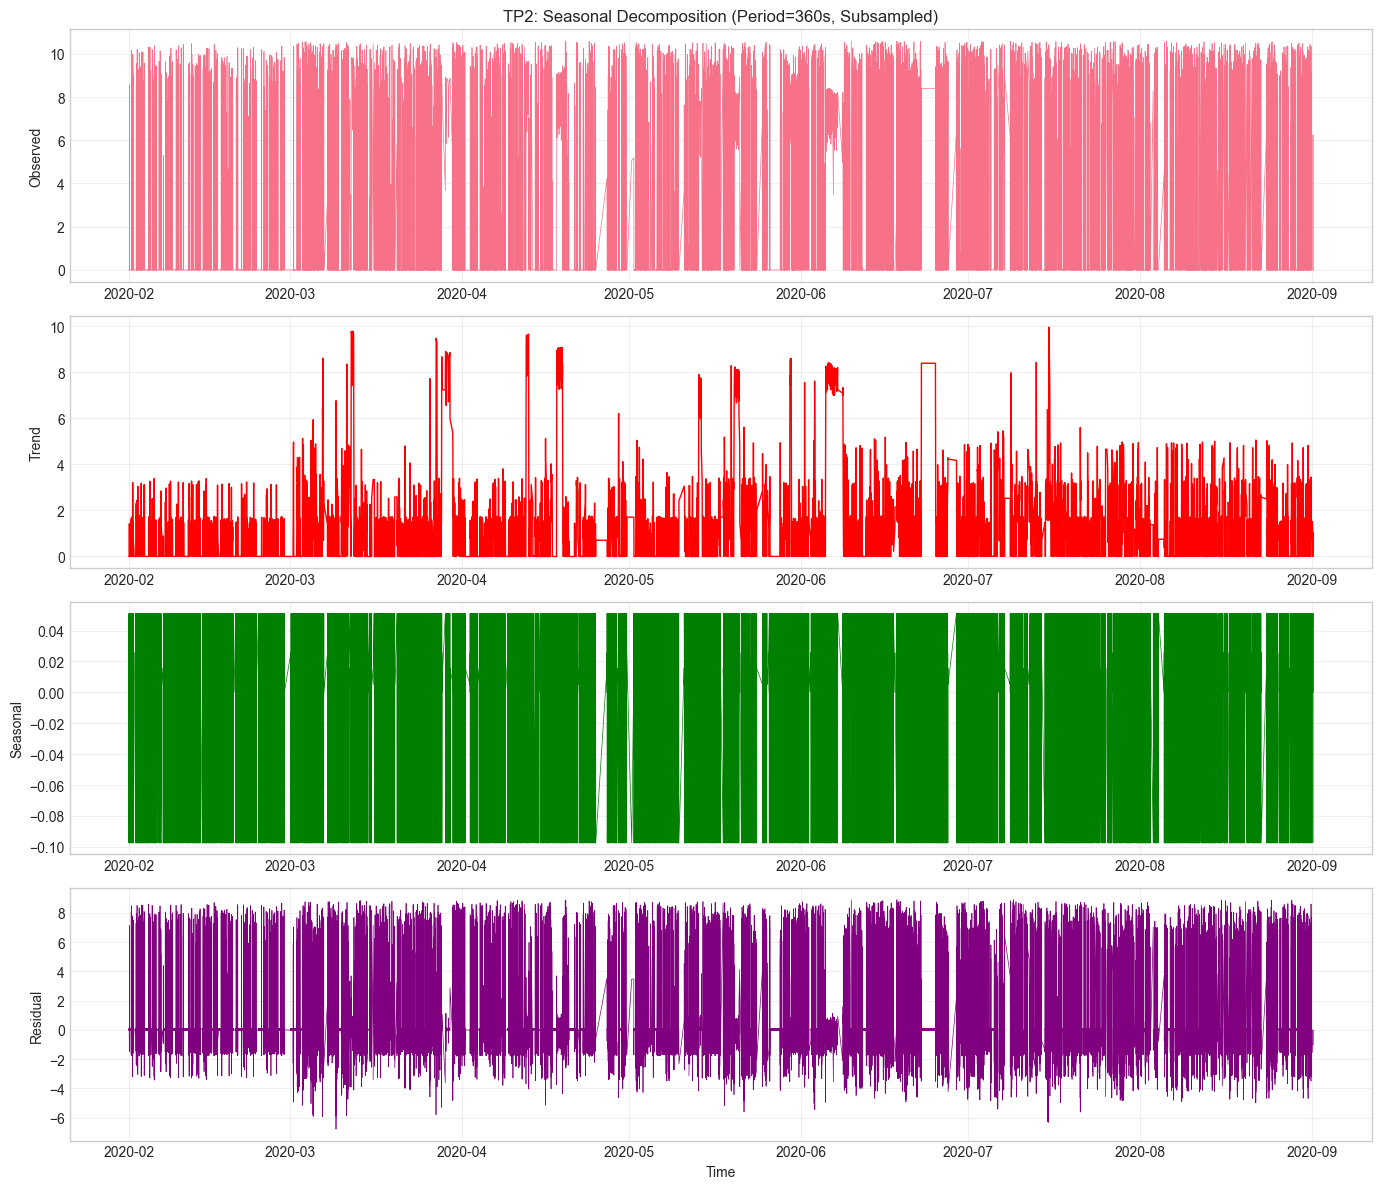

In [13]:
# -----------------------------------------------------------------------------
# 3.4 Seasonal Decomposition
# -----------------------------------------------------------------------------
def perform_seasonal_decomposition(data, sensor, period=360):
    """
    Perform seasonal decomposition using additive model.
    Period: 360 = 1 hour cycle at 0.1Hz (adjust based on domain knowledge)
    
    Note: For industrial APU data, cycles might be related to:
    - Operating cycles
    - Shift patterns (8h = 2880 samples at 0.1Hz)
    - Daily patterns (24h = 8640 samples at 0.1Hz)
    """
    # Subsample for computational efficiency (every 60th point = 1-minute resolution)
    subsample_rate = 60
    series_subsampled = data[sensor].iloc[::subsample_rate]
    
    # Adjust period for subsampled data
    adjusted_period = period // subsample_rate
    
    try:
        # Perform decomposition
        decomposition = seasonal_decompose(
            series_subsampled.dropna(), 
            model='additive', 
            period=adjusted_period
        )
        
        fig, axes = plt.subplots(4, 1, figsize=(14, 12))
        
        axes[0].plot(decomposition.observed, linewidth=0.5)
        axes[0].set_ylabel('Observed')
        axes[0].set_title(f'{sensor}: Seasonal Decomposition (Period={period}s, Subsampled)')
        
        axes[1].plot(decomposition.trend, color='red', linewidth=1)
        axes[1].set_ylabel('Trend')
        
        axes[2].plot(decomposition.seasonal, color='green', linewidth=0.5)
        axes[2].set_ylabel('Seasonal')
        
        axes[3].plot(decomposition.resid, color='purple', linewidth=0.5)
        axes[3].set_ylabel('Residual')
        axes[3].set_xlabel('Time')
        
        for ax in axes:
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return decomposition
        
    except Exception as e:
        print(f"Could not decompose {sensor}: {e}")
        return None

print("SEASONAL DECOMPOSITION")
print("=" * 60)
print("Using 1-hour period (360 samples at 0.1Hz) as base cycle\n")

# Perform decomposition for first key sensor
decomp_result = perform_seasonal_decomposition(df, available_key_sensors[0], period=360)

# Section 4: Stationarity Analysis
Perform Augmented Dickey-Fuller (ADF) tests to assess stationarity and apply differencing if needed.

In [36]:
# -----------------------------------------------------------------------------
# 4.1 Augmented Dickey-Fuller Test Function
# -----------------------------------------------------------------------------
def adf_test(series, sensor_name, significance_level=0.05):
    """
    Perform Augmented Dickey-Fuller test for stationarity.
    
    Null Hypothesis (H0): The series has a unit root (non-stationary)
    Alternative (H1): The series is stationary
    
    If p-value < significance_level: Reject H0 → Series is stationary
    If p-value >= significance_level: Fail to reject H0 → Series is non-stationary
    """
    # Use subset for faster computation (first 100k points)
    sample_size = min(100000, len(series))
    series_sample = series.dropna().iloc[:sample_size]
    
    result = adfuller(series_sample, autolag='AIC')
    
    adf_stat = result[0]
    p_value = result[1]
    used_lag = result[2]
    n_obs = result[3]
    critical_values = result[4]
    
    is_stationary = p_value < significance_level
    
    print(f"\n{'='*60}")
    print(f"ADF TEST: {sensor_name}")
    print(f"{'='*60}")
    print(f"  ADF Statistic: {adf_stat:.6f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Lags Used: {used_lag}")
    print(f"  Observations: {n_obs}")
    print(f"  Critical Values:")
    for key, value in critical_values.items():
        print(f"    {key}: {value:.4f}")
    
    print(f"\n  CONCLUSION (α={significance_level}):")
    if is_stationary:
        print(f"  ✓ STATIONARY - p-value ({p_value:.4f}) < {significance_level}")
        print(f"    The series does not have a unit root.")
    else:
        print(f"  ✗ NON-STATIONARY - p-value ({p_value:.4f}) >= {significance_level}")
        print(f"    The series may have a unit root. Consider differencing.")
    
    return {
        'sensor': sensor_name,
        'adf_statistic': adf_stat,
        'p_value': p_value,
        'is_stationary': is_stationary
    }

In [37]:
# -----------------------------------------------------------------------------
# 4.2 Run ADF Tests on Key Sensors
# -----------------------------------------------------------------------------
print("STATIONARITY ANALYSIS - AUGMENTED DICKEY-FULLER TEST")
print("=" * 60)

stationarity_results = []

for sensor in available_key_sensors:
    result = adf_test(df[sensor], sensor)
    stationarity_results.append(result)

# Summary table
print("\n" + "=" * 60)
print("STATIONARITY SUMMARY")
print("=" * 60)
stationarity_df = pd.DataFrame(stationarity_results)
print(stationarity_df.to_string(index=False))

STATIONARITY ANALYSIS - AUGMENTED DICKEY-FULLER TEST

ADF TEST: TP2
  ADF Statistic: -45.586390
  p-value: 0.000000
  Lags Used: 68
  Observations: 99931
  Critical Values:
    1%: -3.4304
    5%: -2.8616
    10%: -2.5668

  CONCLUSION (α=0.05):
  ✓ STATIONARY - p-value (0.0000) < 0.05
    The series does not have a unit root.

ADF TEST: TP3
  ADF Statistic: -42.154086
  p-value: 0.000000
  Lags Used: 68
  Observations: 99931
  Critical Values:
    1%: -3.4304
    5%: -2.8616
    10%: -2.5668

  CONCLUSION (α=0.05):
  ✓ STATIONARY - p-value (0.0000) < 0.05
    The series does not have a unit root.

ADF TEST: Motor_current
  ADF Statistic: -41.032716
  p-value: 0.000000
  Lags Used: 68
  Observations: 99931
  Critical Values:
    1%: -3.4304
    5%: -2.8616
    10%: -2.5668

  CONCLUSION (α=0.05):
  ✓ STATIONARY - p-value (0.0000) < 0.05
    The series does not have a unit root.

ADF TEST: Oil_temperature
  ADF Statistic: -13.404053
  p-value: 0.000000
  Lags Used: 67
  Observations: 99

DIFFERENCING ANALYSIS


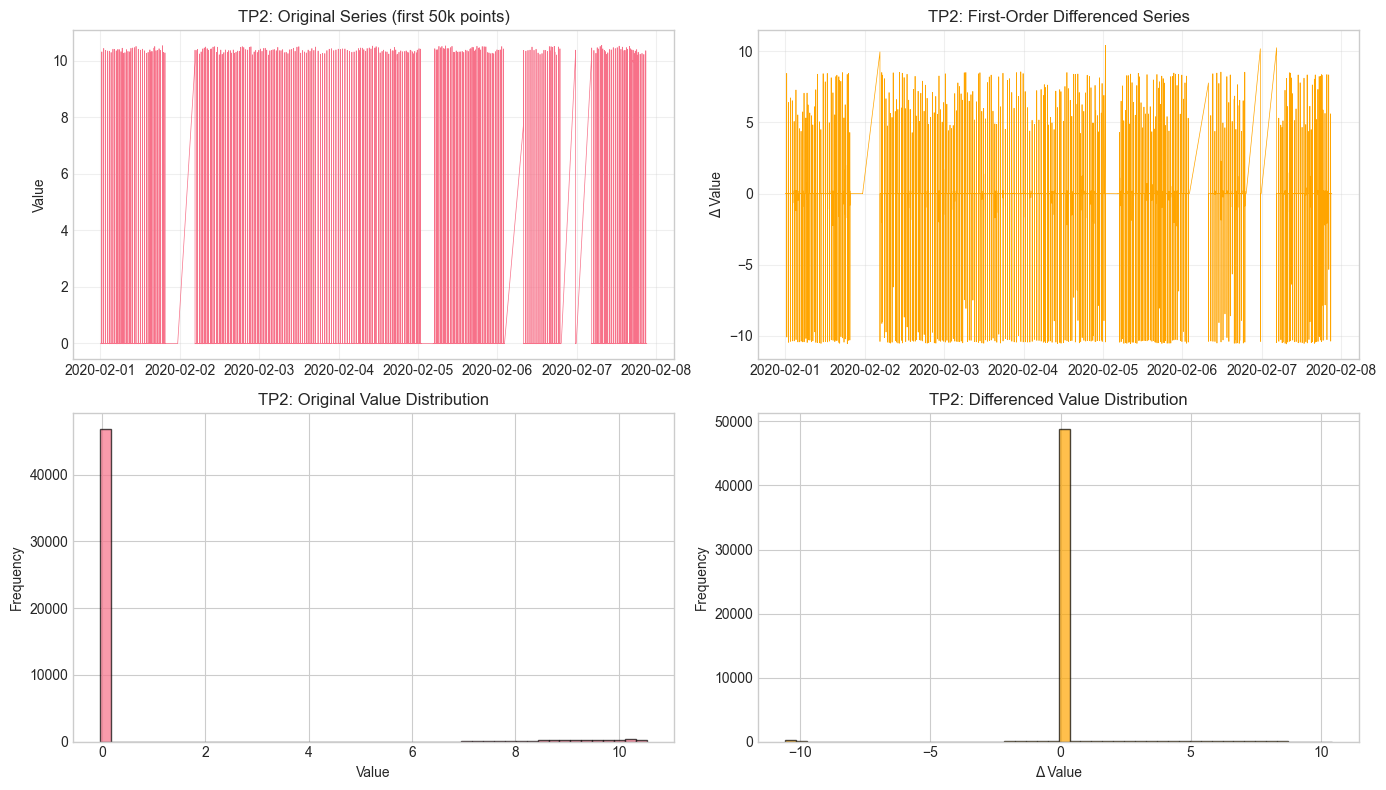


ADF Test on DIFFERENCED TP2:

ADF TEST: TP2 (differenced)
  ADF Statistic: -62.683873
  p-value: 0.000000
  Lags Used: 68
  Observations: 99931
  Critical Values:
    1%: -3.4304
    5%: -2.8616
    10%: -2.5668

  CONCLUSION (α=0.05):
  ✓ STATIONARY - p-value (0.0000) < 0.05
    The series does not have a unit root.


In [38]:
# -----------------------------------------------------------------------------
# 4.3 First-Order Differencing for Non-Stationary Series
# -----------------------------------------------------------------------------
def analyze_differencing(data, sensor):
    """
    Apply first-order differencing and compare stationarity.
    Differencing: y'(t) = y(t) - y(t-1)
    """
    series = data[sensor].dropna()
    series_diff = series.diff().dropna()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # Original series
    axes[0, 0].plot(series.iloc[:50000], linewidth=0.5)
    axes[0, 0].set_title(f'{sensor}: Original Series (first 50k points)')
    axes[0, 0].set_ylabel('Value')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Differenced series
    axes[0, 1].plot(series_diff.iloc[:50000], linewidth=0.5, color='orange')
    axes[0, 1].set_title(f'{sensor}: First-Order Differenced Series')
    axes[0, 1].set_ylabel('Δ Value')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Distribution of original
    axes[1, 0].hist(series.iloc[:50000], bins=50, edgecolor='black', alpha=0.7)
    axes[1, 0].set_title(f'{sensor}: Original Value Distribution')
    axes[1, 0].set_xlabel('Value')
    axes[1, 0].set_ylabel('Frequency')
    
    # Distribution of differenced
    axes[1, 1].hist(series_diff.iloc[:50000], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 1].set_title(f'{sensor}: Differenced Value Distribution')
    axes[1, 1].set_xlabel('Δ Value')
    axes[1, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # Run ADF on differenced series
    print(f"\nADF Test on DIFFERENCED {sensor}:")
    adf_test(series_diff, f"{sensor} (differenced)")

print("DIFFERENCING ANALYSIS")
print("=" * 60)

# Apply differencing to first non-stationary sensor (or first sensor if all stationary)
non_stationary = [r['sensor'] for r in stationarity_results if not r['is_stationary']]
sensor_to_diff = non_stationary[0] if non_stationary else available_key_sensors[0]

analyze_differencing(df, sensor_to_diff)

# Section 5: Temporal Dependency
Analyze autocorrelation (ACF) and partial autocorrelation (PACF) to understand short-term and long-term dependencies.

AUTOCORRELATION ANALYSIS
Analyzing temporal dependencies in sensor signals...
Max lags: 100 samples (~17 minutes at 0.1Hz)



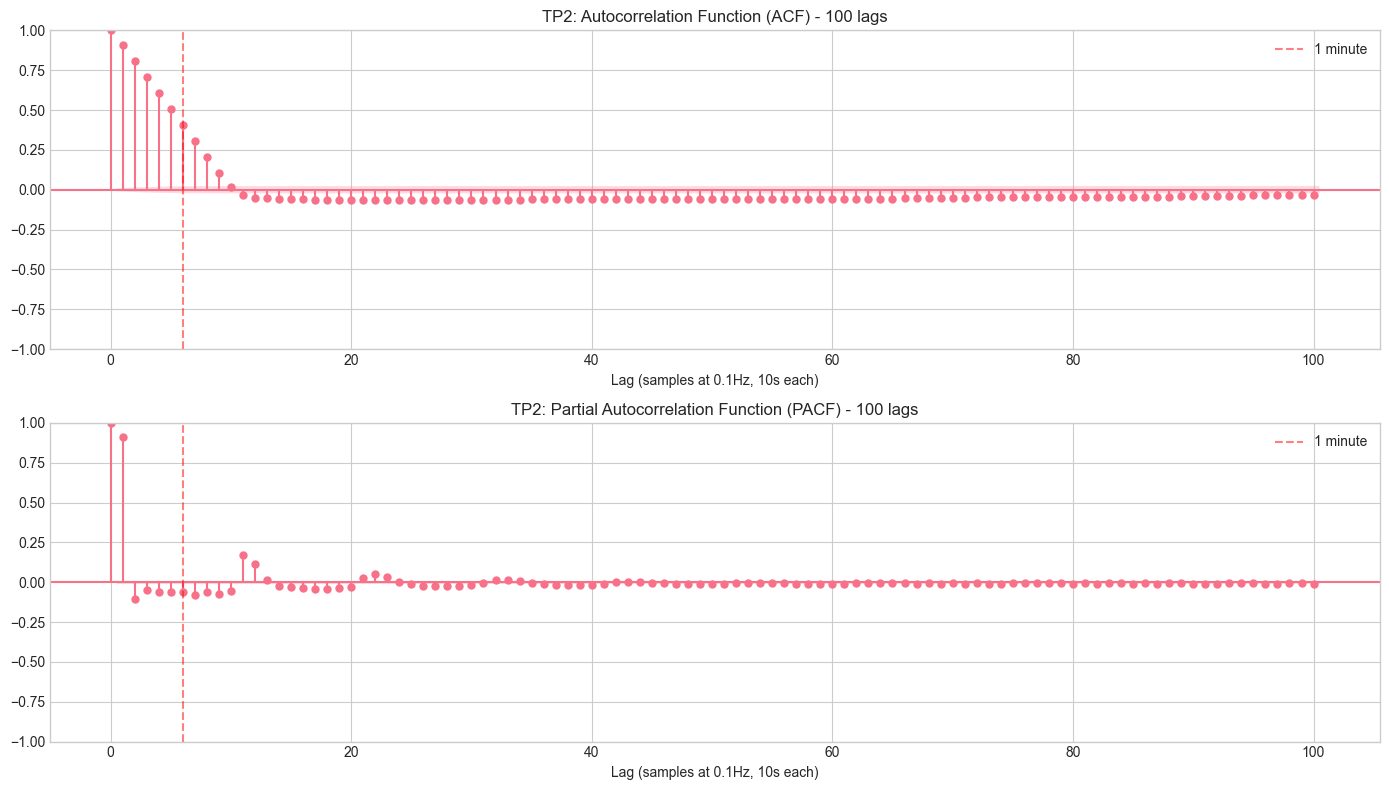


TEMPORAL DEPENDENCY ANALYSIS: TP2
------------------------------------------------------------
  Short-term dependency (lags 1-10): Mean |ACF| = 0.4575
  Medium-term dependency (lags 10-60): Mean |ACF| = 0.0588
  Long-term dependency (lags 60-100): Mean |ACF| = 0.0462


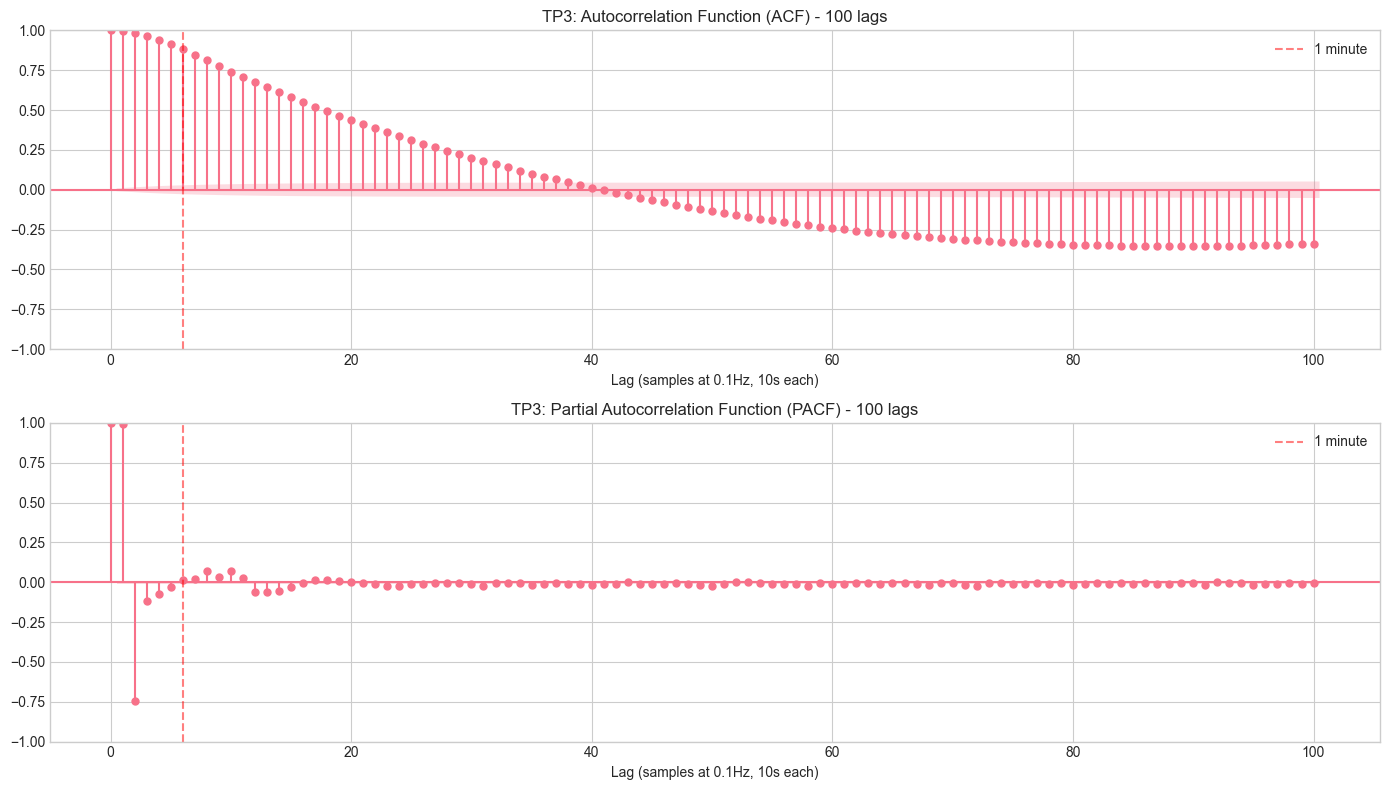


TEMPORAL DEPENDENCY ANALYSIS: TP3
------------------------------------------------------------
  Short-term dependency (lags 1-10): Mean |ACF| = 0.8850
  Medium-term dependency (lags 10-60): Mean |ACF| = 0.2561
  Long-term dependency (lags 60-100): Mean |ACF| = 0.3252
  → Strong short-term autocorrelation detected
    Implication: Consider AR models or LSTM with short lookback windows
  → Significant long-term dependency detected
    Implication: May need longer context windows for anomaly detection


In [39]:
# -----------------------------------------------------------------------------
# 5.1 ACF and PACF Analysis
# -----------------------------------------------------------------------------
def plot_acf_pacf(data, sensor, max_lags=100):
    """
    Plot ACF and PACF for temporal dependency analysis.
    
    ACF (Autocorrelation Function):
    - Shows correlation between series and its lagged versions
    - Slow decay indicates strong temporal dependency
    
    PACF (Partial Autocorrelation Function):
    - Shows direct correlation at each lag (controlling for shorter lags)
    - Helps identify AR order in ARIMA models
    
    For 0.1Hz industrial data (10s per sample):
    - lag=6 → 1 minute
    - lag=360 → 1 hour
    """
    series = data[sensor].dropna().iloc[:50000]  # Subsample for efficiency
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # ACF plot
    plot_acf(series, ax=axes[0], lags=max_lags, alpha=0.05)
    axes[0].set_title(f'{sensor}: Autocorrelation Function (ACF) - {max_lags} lags')
    axes[0].set_xlabel('Lag (samples at 0.1Hz, 10s each)')
    axes[0].axvline(x=6, color='red', linestyle='--', alpha=0.5, label='1 minute')
    axes[0].legend()
    
    # PACF plot
    plot_pacf(series, ax=axes[1], lags=max_lags, alpha=0.05, method='ywm')
    axes[1].set_title(f'{sensor}: Partial Autocorrelation Function (PACF) - {max_lags} lags')
    axes[1].set_xlabel('Lag (samples at 0.1Hz, 10s each)')
    axes[1].axvline(x=6, color='red', linestyle='--', alpha=0.5, label='1 minute')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Interpretation comments
    print(f"\nTEMPORAL DEPENDENCY ANALYSIS: {sensor}")
    print("-" * 60)
    
    # Calculate ACF values for interpretation
    acf_values = acf(series, nlags=max_lags)
    
    # Check short-term dependency (first 10 lags)
    short_term_acf = np.mean(np.abs(acf_values[1:11]))
    print(f"  Short-term dependency (lags 1-10): Mean |ACF| = {short_term_acf:.4f}")
    
    # Check medium-term dependency (lags 10-60)
    medium_term_acf = np.mean(np.abs(acf_values[10:61]))
    print(f"  Medium-term dependency (lags 10-60): Mean |ACF| = {medium_term_acf:.4f}")
    
    # Check long-term dependency (lags 60-100)
    long_term_acf = np.mean(np.abs(acf_values[60:]))
    print(f"  Long-term dependency (lags 60-100): Mean |ACF| = {long_term_acf:.4f}")
    
    if short_term_acf > 0.5:
        print("  → Strong short-term autocorrelation detected")
        print("    Implication: Consider AR models or LSTM with short lookback windows")
    if long_term_acf > 0.2:
        print("  → Significant long-term dependency detected")
        print("    Implication: May need longer context windows for anomaly detection")

print("AUTOCORRELATION ANALYSIS")
print("=" * 60)
print("Analyzing temporal dependencies in sensor signals...")
print("Max lags: 100 samples (~17 minutes at 0.1Hz)\n")

for sensor in available_key_sensors[:2]:  # Limit to first 2 for brevity
    plot_acf_pacf(df, sensor, max_lags=100)

# Section 6: Variance & Volatility Analysis
Compute rolling variance, detect variance shifts over time, and assess heteroscedasticity.

VARIANCE & VOLATILITY ANALYSIS
Window size: 360 samples (1 hour at 0.1Hz)



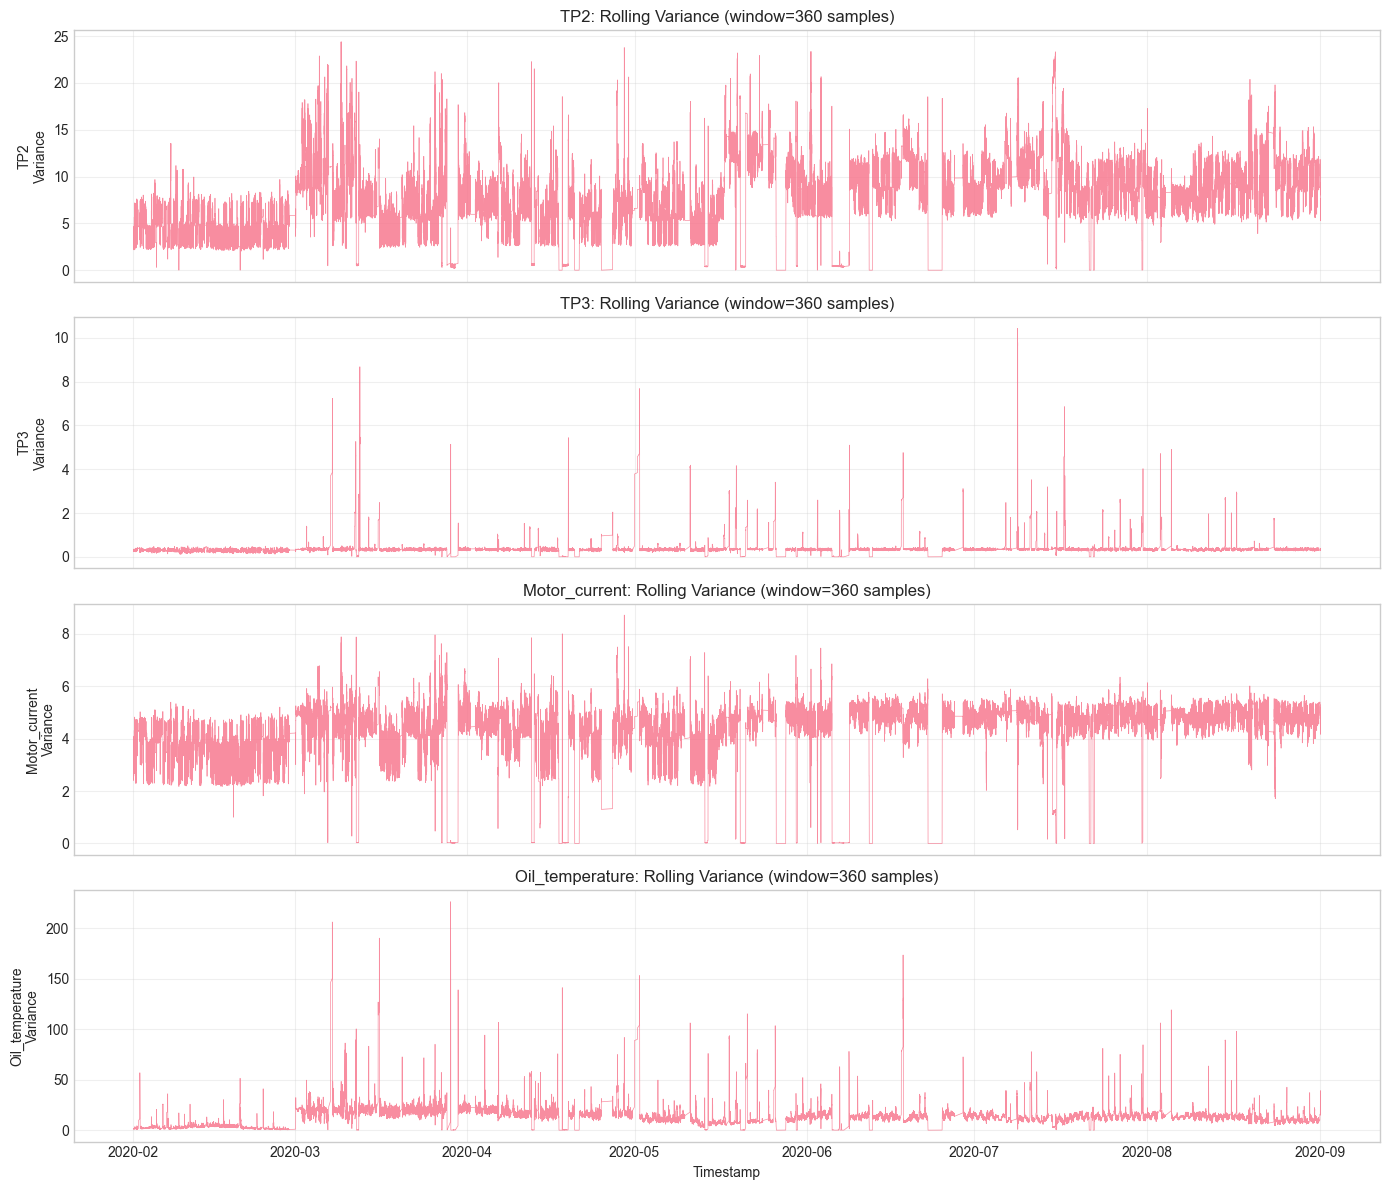


VARIANCE STATISTICS
------------------------------------------------------------
         sensor  mean_variance  std_variance  cv_variance
            TP2         7.6561        3.6800       0.4807
            TP3         0.3444        0.3715       1.0787
  Motor_current         4.1833        1.3326       0.3186
Oil_temperature        12.6824       10.4545       0.8243

HETEROSCEDASTICITY INTERPRETATION:
------------------------------------------------------------
  TP2: LOW heteroscedasticity (CV=0.48)
    → Relatively constant variance
  TP3: HIGH heteroscedasticity (CV=1.08)
    → Variance changes significantly over time
    → Consider variance-stabilizing transforms or GARCH models
  Motor_current: LOW heteroscedasticity (CV=0.32)
    → Relatively constant variance
  Oil_temperature: MODERATE heteroscedasticity (CV=0.82)
    → Some variance shifts present


In [42]:
# -----------------------------------------------------------------------------
# 6.1 Rolling Variance Analysis
# -----------------------------------------------------------------------------
def analyze_variance(data, sensors, window_size=360):
    """
    Analyze rolling variance to detect heteroscedasticity and variance shifts.
    
    Heteroscedasticity (non-constant variance) is important because:
    - It affects model assumptions (many models assume constant variance)
    - Variance shifts may indicate operational mode changes or degradation
    - For PdM: increasing variance often precedes failures
    
    At 0.1Hz: window_size=360 samples = 1 hour
    """
    n_sensors = len(sensors)
    fig, axes = plt.subplots(n_sensors, 1, figsize=(14, 3*n_sensors), sharex=True)
    
    if n_sensors == 1:
        axes = [axes]
    
    variance_stats = []
    
    for ax, sensor in zip(axes, sensors):
        series = data[sensor]
        rolling_var = series.rolling(window=window_size).var()
        
        ax.plot(data.index, rolling_var, linewidth=0.5, alpha=0.8)
        ax.set_ylabel(f'{sensor}\nVariance')
        ax.set_title(f'{sensor}: Rolling Variance (window={window_size} samples)')
        ax.grid(True, alpha=0.3)
        
        # Calculate variance statistics
        var_mean = rolling_var.mean()
        var_std = rolling_var.std()
        var_cv = var_std / var_mean if var_mean > 0 else 0
        
        variance_stats.append({
            'sensor': sensor,
            'mean_variance': var_mean,
            'std_variance': var_std,
            'cv_variance': var_cv  # Coefficient of variation of variance
        })
    
    axes[-1].set_xlabel('Timestamp')
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(variance_stats)

print("VARIANCE & VOLATILITY ANALYSIS")
print("=" * 60)
print(f"Window size: 360 samples (1 hour at 0.1Hz)\n")

variance_df = analyze_variance(df, available_key_sensors, window_size=360)

print("\nVARIANCE STATISTICS")
print("-" * 60)
print(variance_df.to_string(index=False))

print("\nHETEROSCEDASTICITY INTERPRETATION:")
print("-" * 60)
for _, row in variance_df.iterrows():
    cv = row['cv_variance']
    sensor = row['sensor']
    if cv > 1.0:
        print(f"  {sensor}: HIGH heteroscedasticity (CV={cv:.2f})")
        print(f"    → Variance changes significantly over time")
        print(f"    → Consider variance-stabilizing transforms or GARCH models")
    elif cv > 0.5:
        print(f"  {sensor}: MODERATE heteroscedasticity (CV={cv:.2f})")
        print(f"    → Some variance shifts present")
    else:
        print(f"  {sensor}: LOW heteroscedasticity (CV={cv:.2f})")
        print(f"    → Relatively constant variance")

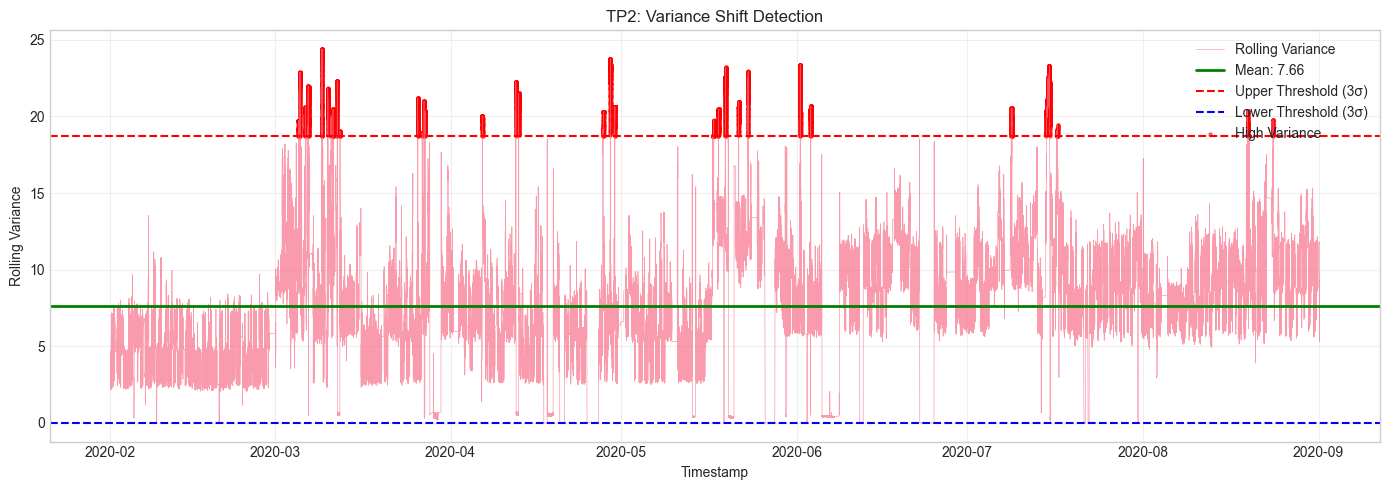


VARIANCE SHIFT SUMMARY: TP2
------------------------------------------------------------
  Total variance observations: 1,516,589
  High variance periods: 12,900 (0.85%)
  Low variance periods: 0 (0.00%)


In [43]:
# -----------------------------------------------------------------------------
# 6.2 Variance Shift Detection
# -----------------------------------------------------------------------------
def detect_variance_shifts(data, sensor, window_size=360, threshold_std=3):
    """
    Detect significant variance shifts that may indicate:
    - Operating mode changes
    - Equipment degradation
    - Anomalous periods
    
    At 0.1Hz: window_size=360 samples = 1 hour
    """
    series = data[sensor]
    rolling_var = series.rolling(window=window_size).var().dropna()
    
    # Calculate global statistics
    global_mean = rolling_var.mean()
    global_std = rolling_var.std()
    
    # Identify variance shifts (beyond threshold standard deviations)
    upper_threshold = global_mean + threshold_std * global_std
    lower_threshold = max(0, global_mean - threshold_std * global_std)
    
    high_variance_periods = rolling_var[rolling_var > upper_threshold]
    low_variance_periods = rolling_var[rolling_var < lower_threshold]
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.plot(rolling_var.index, rolling_var, linewidth=0.5, alpha=0.7, label='Rolling Variance')
    ax.axhline(y=global_mean, color='green', linestyle='-', linewidth=2, label=f'Mean: {global_mean:.2f}')
    ax.axhline(y=upper_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Upper Threshold ({threshold_std}σ)')
    ax.axhline(y=lower_threshold, color='blue', linestyle='--', linewidth=1.5, label=f'Lower Threshold ({threshold_std}σ)')
    
    # Highlight anomalous periods
    if len(high_variance_periods) > 0:
        ax.scatter(high_variance_periods.index, high_variance_periods, 
                   color='red', s=5, alpha=0.5, label='High Variance')
    
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Rolling Variance')
    ax.set_title(f'{sensor}: Variance Shift Detection')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nVARIANCE SHIFT SUMMARY: {sensor}")
    print("-" * 60)
    print(f"  Total variance observations: {len(rolling_var):,}")
    print(f"  High variance periods: {len(high_variance_periods):,} ({100*len(high_variance_periods)/len(rolling_var):.2f}%)")
    print(f"  Low variance periods: {len(low_variance_periods):,} ({100*len(low_variance_periods)/len(rolling_var):.2f}%)")

# Detect variance shifts for key sensor
detect_variance_shifts(df, available_key_sensors[0], window_size=360, threshold_std=3)

# Section 7: Outlier & Anomaly Exploration (EDA-level)
Detect outliers using statistical methods (IQR, Z-score) and visualize potential anomaly periods without removing data.

In [44]:
# -----------------------------------------------------------------------------
# 7.1 IQR-Based Outlier Detection
# -----------------------------------------------------------------------------
def detect_outliers_iqr(data, sensor, k=1.5):
    """
    Detect outliers using the Interquartile Range (IQR) method.
    
    Outlier definition:
    - Lower bound: Q1 - k * IQR
    - Upper bound: Q3 + k * IQR
    
    k=1.5 is standard for mild outliers
    k=3.0 is used for extreme outliers
    """
    series = data[sensor].dropna()
    
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR
    
    outliers_mask = (series < lower_bound) | (series > upper_bound)
    outliers = series[outliers_mask]
    
    return {
        'sensor': sensor,
        'method': 'IQR',
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_outliers': len(outliers),
        'pct_outliers': 100 * len(outliers) / len(series),
        'outliers_mask': outliers_mask
    }

def detect_outliers_zscore(data, sensor, threshold=3):
    """
    Detect outliers using Z-score method.
    
    Outlier definition: |z-score| > threshold
    
    threshold=3 corresponds to ~0.3% of data in normal distribution
    """
    series = data[sensor].dropna()
    
    mean = series.mean()
    std = series.std()
    
    z_scores = np.abs((series - mean) / std)
    outliers_mask = z_scores > threshold
    outliers = series[outliers_mask]
    
    return {
        'sensor': sensor,
        'method': 'Z-score',
        'mean': mean,
        'std': std,
        'threshold': threshold,
        'n_outliers': len(outliers),
        'pct_outliers': 100 * len(outliers) / len(series),
        'outliers_mask': outliers_mask
    }

print("OUTLIER DETECTION ANALYSIS")
print("=" * 60)

OUTLIER DETECTION ANALYSIS


In [45]:
# -----------------------------------------------------------------------------
# 7.2 Run Outlier Detection on All Key Sensors
# -----------------------------------------------------------------------------
outlier_results_iqr = []
outlier_results_zscore = []

for sensor in available_key_sensors:
    iqr_result = detect_outliers_iqr(df, sensor, k=1.5)
    zscore_result = detect_outliers_zscore(df, sensor, threshold=3)
    
    outlier_results_iqr.append({
        'Sensor': sensor,
        'Lower Bound': iqr_result['lower_bound'],
        'Upper Bound': iqr_result['upper_bound'],
        'Outliers': iqr_result['n_outliers'],
        'Outliers %': iqr_result['pct_outliers']
    })
    
    outlier_results_zscore.append({
        'Sensor': sensor,
        'Mean': zscore_result['mean'],
        'Std': zscore_result['std'],
        'Outliers': zscore_result['n_outliers'],
        'Outliers %': zscore_result['pct_outliers']
    })

print("IQR METHOD RESULTS (k=1.5)")
print("-" * 60)
iqr_df = pd.DataFrame(outlier_results_iqr)
print(iqr_df.to_string(index=False))

print("\n\nZ-SCORE METHOD RESULTS (threshold=3)")
print("-" * 60)
zscore_df = pd.DataFrame(outlier_results_zscore)
print(zscore_df.to_string(index=False))

IQR METHOD RESULTS (k=1.5)
------------------------------------------------------------
         Sensor  Lower Bound  Upper Bound  Outliers  Outliers %
            TP2      -0.0200      -0.0040    269592     17.7720
            TP3       6.9920      10.9920      4518      0.2978
  Motor_current      -5.6113       9.4588         0      0.0000
Oil_temperature      43.5625      81.4625      5194      0.3424


Z-SCORE METHOD RESULTS (threshold=3)
------------------------------------------------------------
         Sensor    Mean    Std  Outliers  Outliers %
            TP2  1.3678 3.2509         0      0.0000
            TP3  8.9846 0.6391      4652      0.3067
  Motor_current  2.0502 2.3021         7      0.0005
Oil_temperature 62.6442 6.5163      4084      0.2692



OUTLIER VISUALIZATION


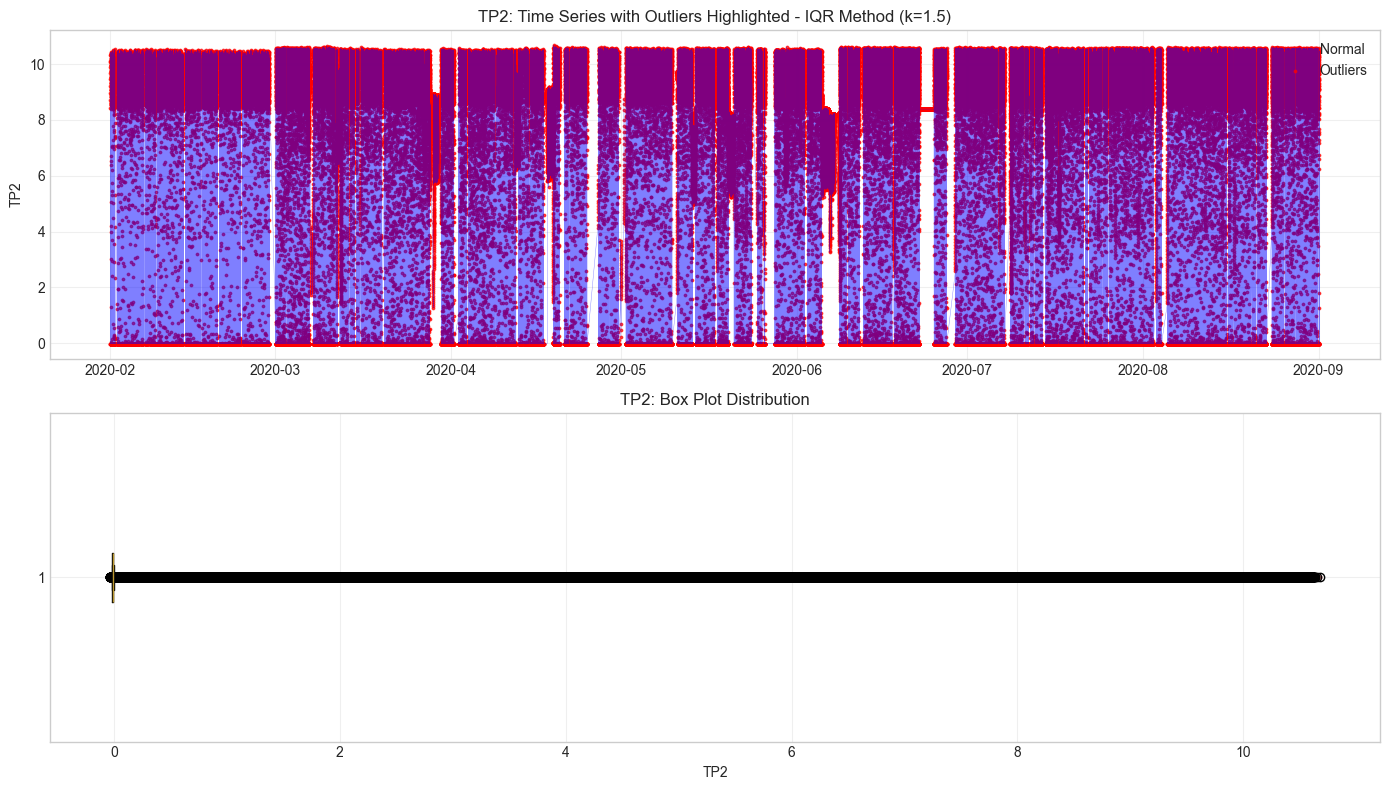


TP2 - IQR Method (k=1.5):
  Total points: 1,516,948
  Outliers: 269,592 (17.77%)


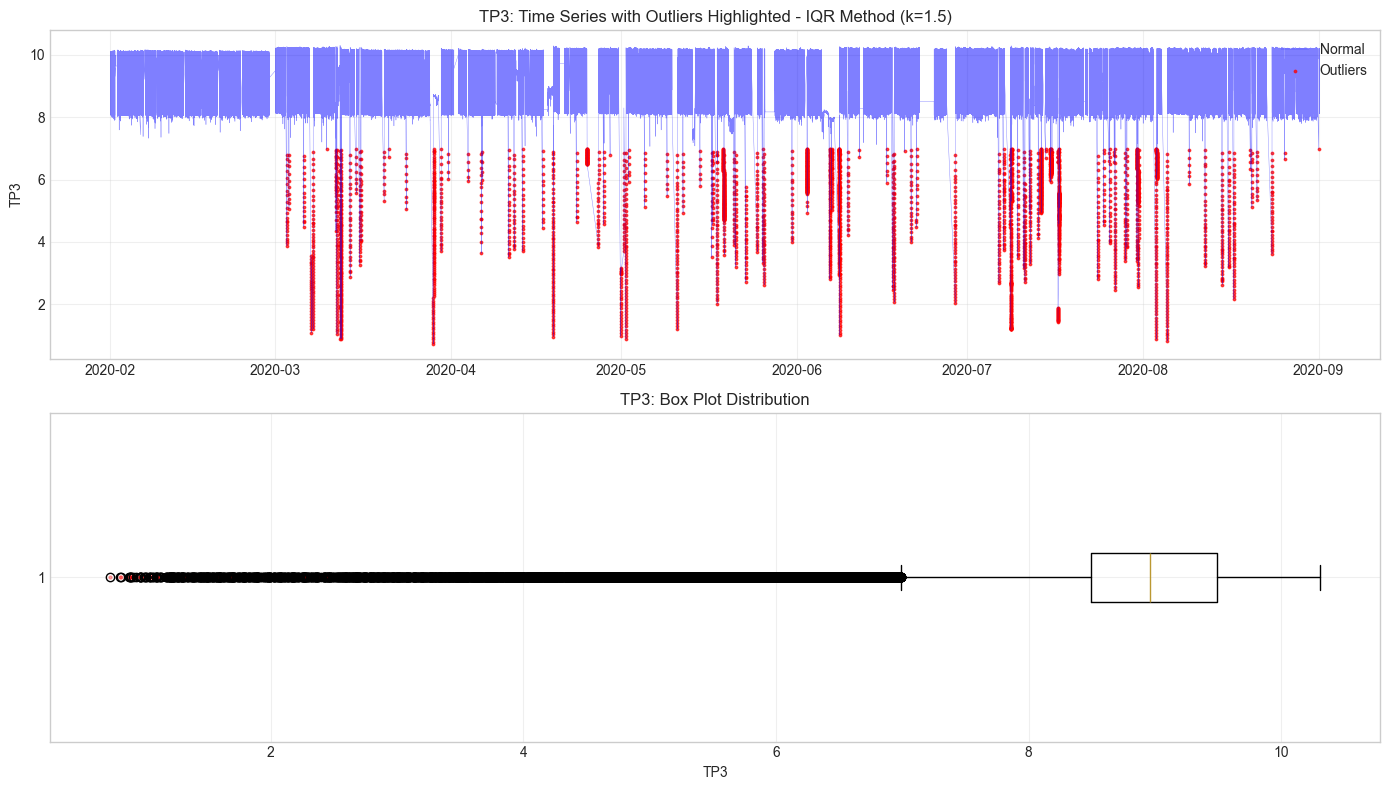


TP3 - IQR Method (k=1.5):
  Total points: 1,516,948
  Outliers: 4,518 (0.30%)


In [46]:
# -----------------------------------------------------------------------------
# 7.3 Visualize Outliers on Time Series
# -----------------------------------------------------------------------------
def plot_outliers_timeseries(data, sensor, method='iqr', k=1.5, z_threshold=3):
    """
    Plot time series with outliers highlighted.
    NOTE: This is EDA visualization - outliers are NOT removed.
    """
    series = data[sensor].dropna()
    
    if method == 'iqr':
        result = detect_outliers_iqr(data, sensor, k=k)
        title_suffix = f"IQR Method (k={k})"
    else:
        result = detect_outliers_zscore(data, sensor, threshold=z_threshold)
        title_suffix = f"Z-score Method (threshold={z_threshold})"
    
    outliers_mask = result['outliers_mask']
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Full time series with outliers highlighted
    axes[0].plot(series.index, series, linewidth=0.3, alpha=0.5, label='Normal', color='blue')
    axes[0].scatter(series[outliers_mask].index, series[outliers_mask], 
                    color='red', s=3, alpha=0.7, label='Outliers')
    axes[0].set_ylabel(sensor)
    axes[0].set_title(f'{sensor}: Time Series with Outliers Highlighted - {title_suffix}')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Box plot showing outlier distribution
    axes[1].boxplot(series, vert=False)
    axes[1].scatter(series[outliers_mask], [1]*sum(outliers_mask), 
                    color='red', s=5, alpha=0.3, label='Outliers')
    axes[1].set_xlabel(sensor)
    axes[1].set_title(f'{sensor}: Box Plot Distribution')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{sensor} - {title_suffix}:")
    print(f"  Total points: {len(series):,}")
    print(f"  Outliers: {result['n_outliers']:,} ({result['pct_outliers']:.2f}%)")

print("\nOUTLIER VISUALIZATION")
print("=" * 60)

# Visualize outliers for key sensors
for sensor in available_key_sensors[:2]:  # Limit to first 2 for brevity
    plot_outliers_timeseries(df, sensor, method='iqr', k=1.5)


ANOMALY PERIOD IDENTIFICATION


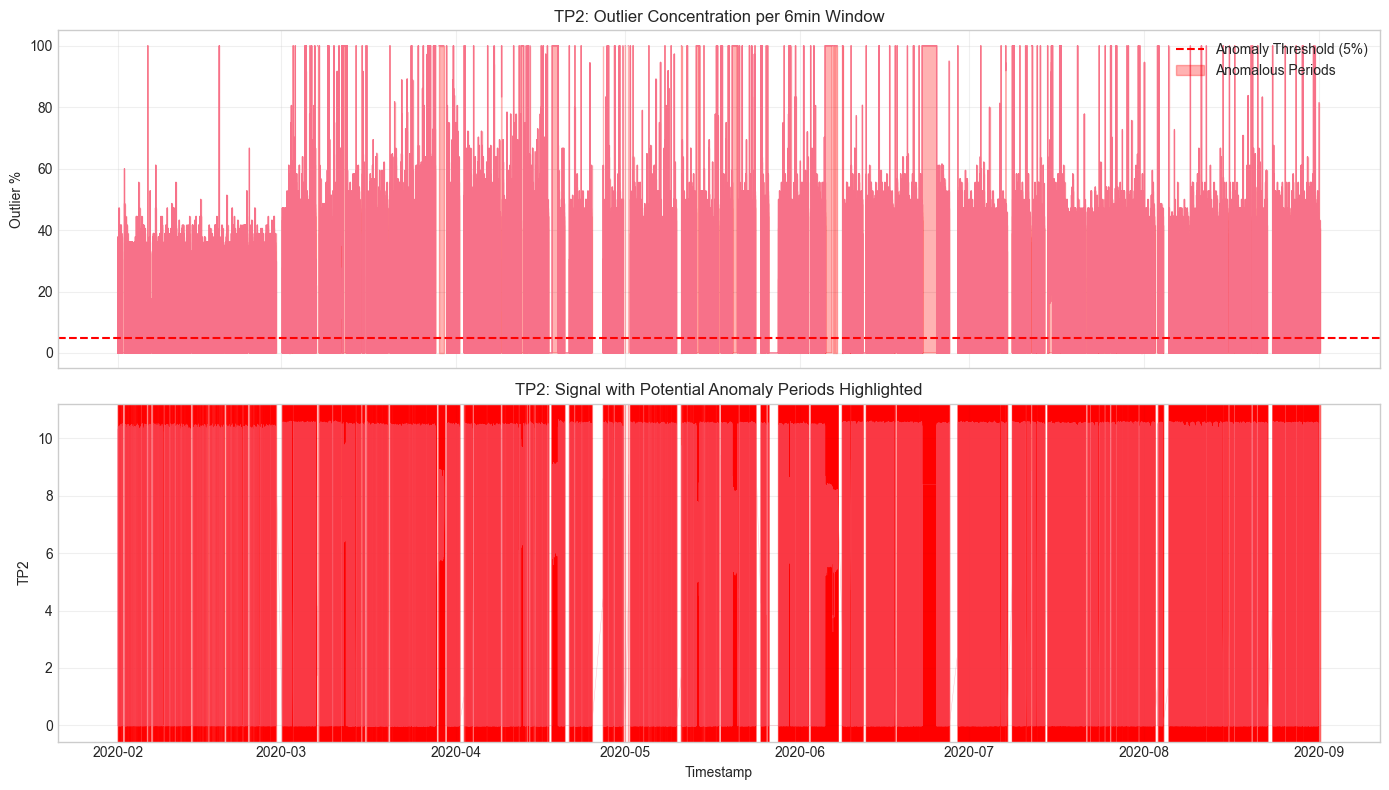


POTENTIAL ANOMALY PERIODS: TP2
------------------------------------------------------------
  Window size: 6min
  Total windows: 51,160
  Anomalous windows (>5% outliers): 17,268
  Percentage of anomalous time: 33.75%

  Top 5 most anomalous periods:
    1. 2020-02-06 07:48:00: 100.0% outliers
    2. 2020-02-19 00:18:00: 100.0% outliers
    3. 2020-03-03 02:48:00: 100.0% outliers
    4. 2020-03-03 11:36:00: 100.0% outliers
    5. 2020-03-05 04:12:00: 100.0% outliers


In [51]:
# -----------------------------------------------------------------------------
# 7.4 Identify Potential Anomaly Periods (Clustered Outliers)
# -----------------------------------------------------------------------------
def identify_anomaly_periods(data, sensor, window='1H', outlier_threshold_pct=5):
    """
    Identify time periods with high concentration of outliers.
    These periods may indicate anomalous equipment behavior.
    
    Parameters:
    - window: Time window for aggregation (e.g., '6min', '1H')
    - outlier_threshold_pct: Percentage threshold to flag a period as anomalous
    """
    result = detect_outliers_iqr(data, sensor, k=1.5)
    outliers_mask = result['outliers_mask']
    
    # Create a series of outlier flags aligned with the original data index
    # Use reindex to handle any index mismatches from dropna in outlier detection
    outlier_series = pd.Series(0, index=data.index)
    outlier_series.loc[outliers_mask.index] = outliers_mask.astype(int)
    
    # Resample to count outliers per window
    outliers_per_window = outlier_series.resample(window).sum()
    points_per_window = outlier_series.resample(window).count()
    outlier_pct_per_window = 100 * outliers_per_window / points_per_window
    
    # Identify anomalous periods
    anomalous_periods = outlier_pct_per_window[outlier_pct_per_window > outlier_threshold_pct]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Outlier percentage over time
    axes[0].plot(outlier_pct_per_window.index, outlier_pct_per_window, linewidth=1)
    axes[0].axhline(y=outlier_threshold_pct, color='red', linestyle='--', 
                    label=f'Anomaly Threshold ({outlier_threshold_pct}%)')
    axes[0].fill_between(outlier_pct_per_window.index, outlier_pct_per_window, 
                         where=outlier_pct_per_window > outlier_threshold_pct,
                         color='red', alpha=0.3, label='Anomalous Periods')
    axes[0].set_ylabel('Outlier %')
    axes[0].set_title(f'{sensor}: Outlier Concentration per {window} Window')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Original signal with anomalous periods highlighted
    axes[1].plot(data.index, data[sensor], linewidth=0.3, alpha=0.5)
    
    # Highlight anomalous periods on the original signal
    for period_start in anomalous_periods.index:
        period_end = period_start + pd.Timedelta(window)
        axes[1].axvspan(period_start, period_end, color='red', alpha=0.2)
    
    axes[1].set_ylabel(sensor)
    axes[1].set_xlabel('Timestamp')
    axes[1].set_title(f'{sensor}: Signal with Potential Anomaly Periods Highlighted')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPOTENTIAL ANOMALY PERIODS: {sensor}")
    print("-" * 60)
    print(f"  Window size: {window}")
    print(f"  Total windows: {len(outlier_pct_per_window):,}")
    print(f"  Anomalous windows (>{outlier_threshold_pct}% outliers): {len(anomalous_periods):,}")
    print(f"  Percentage of anomalous time: {100*len(anomalous_periods)/len(outlier_pct_per_window):.2f}%")
    
    if len(anomalous_periods) > 0:
        print(f"\n  Top 5 most anomalous periods:")
        for i, (idx, val) in enumerate(anomalous_periods.nlargest(5).items()):
            print(f"    {i+1}. {idx}: {val:.1f}% outliers")

print("\nANOMALY PERIOD IDENTIFICATION")
print("=" * 60)

# Identify anomaly periods for first key sensor
# Using '6min' instead of '0.1H' (6 minutes = 0.1 hours, pandas doesn't support decimal hours)
identify_anomaly_periods(df, available_key_sensors[0], window='6min', outlier_threshold_pct=5)

# Section 8: Multivariate Relationships
Analyze correlations between sensors and identify redundancy and coupling patterns.

MULTIVARIATE CORRELATION ANALYSIS


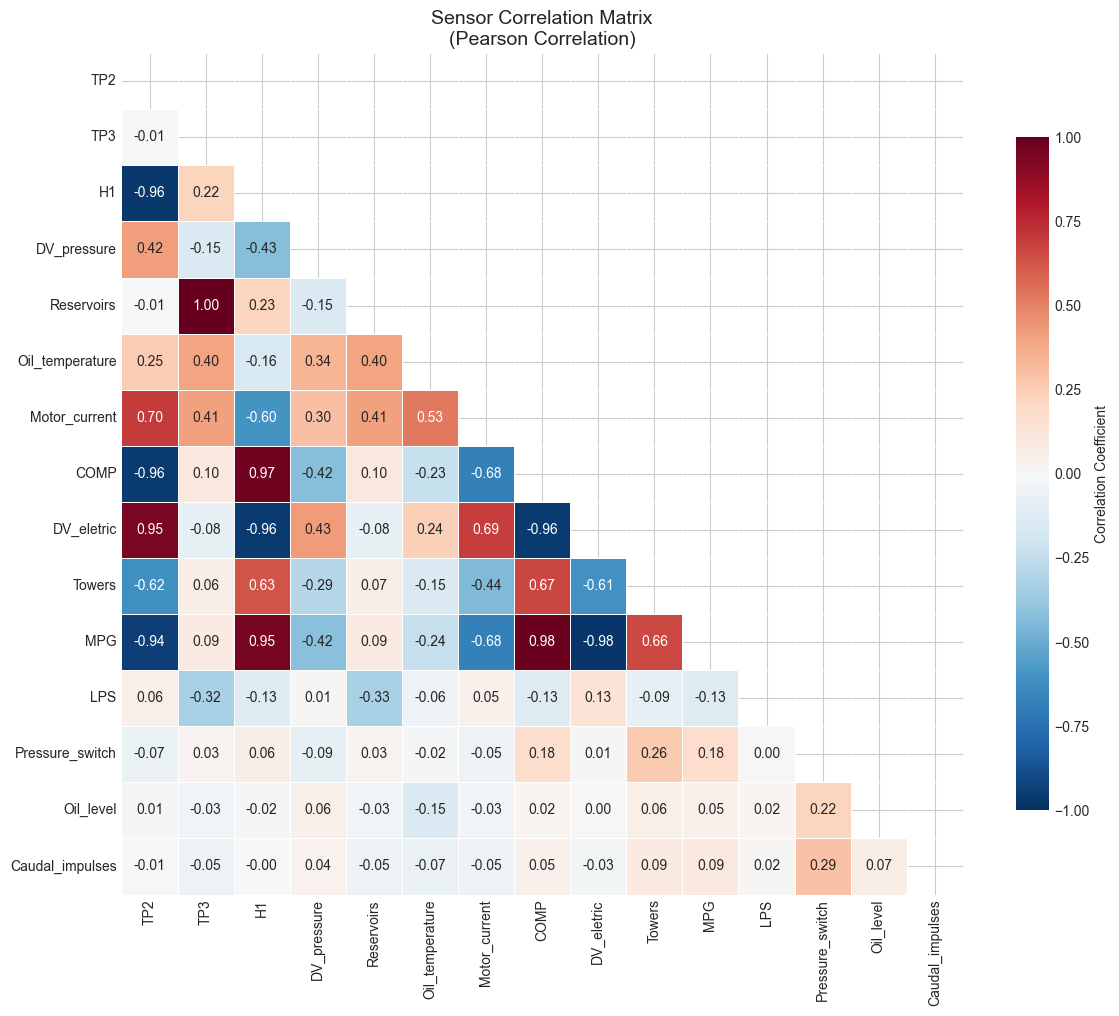


HIGHLY CORRELATED SENSOR PAIRS (|r| > 0.7)
------------------------------------------------------------
  Sensor 1   Sensor 2  Correlation
       TP3 Reservoirs       1.0000
      COMP        MPG       0.9846
DV_eletric        MPG      -0.9756
        H1       COMP       0.9714
       TP2         H1      -0.9613
      COMP DV_eletric      -0.9593
        H1 DV_eletric      -0.9587
       TP2       COMP      -0.9555
        H1        MPG       0.9543
       TP2 DV_eletric       0.9474
       TP2        MPG      -0.9412

IMPLICATIONS FOR MODELING:
  - Highly correlated sensors may provide redundant information
  - Consider feature selection or PCA for dimensionality reduction
  - Correlated sensors failing together may indicate common cause failures


In [52]:
# -----------------------------------------------------------------------------
# 8.1 Correlation Matrix
# -----------------------------------------------------------------------------
print("MULTIVARIATE CORRELATION ANALYSIS")
print("=" * 60)

# Compute correlation matrix for all numeric columns
correlation_matrix = df.corr()

# Create heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Upper triangle mask

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)

plt.title('Sensor Correlation Matrix\n(Pearson Correlation)', fontsize=14)
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
print("\nHIGHLY CORRELATED SENSOR PAIRS (|r| > 0.7)")
print("-" * 60)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append({
                'Sensor 1': correlation_matrix.columns[i],
                'Sensor 2': correlation_matrix.columns[j],
                'Correlation': corr_val
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
    
    print("\nIMPLICATIONS FOR MODELING:")
    print("  - Highly correlated sensors may provide redundant information")
    print("  - Consider feature selection or PCA for dimensionality reduction")
    print("  - Correlated sensors failing together may indicate common cause failures")
else:
    print("  No highly correlated pairs found (|r| > 0.7)")


PAIRWISE SENSOR RELATIONSHIPS
Visualizing relationships between: ['TP2', 'TP3', 'Motor_current', 'Oil_temperature']
(Using 10,000 sample points for efficiency)



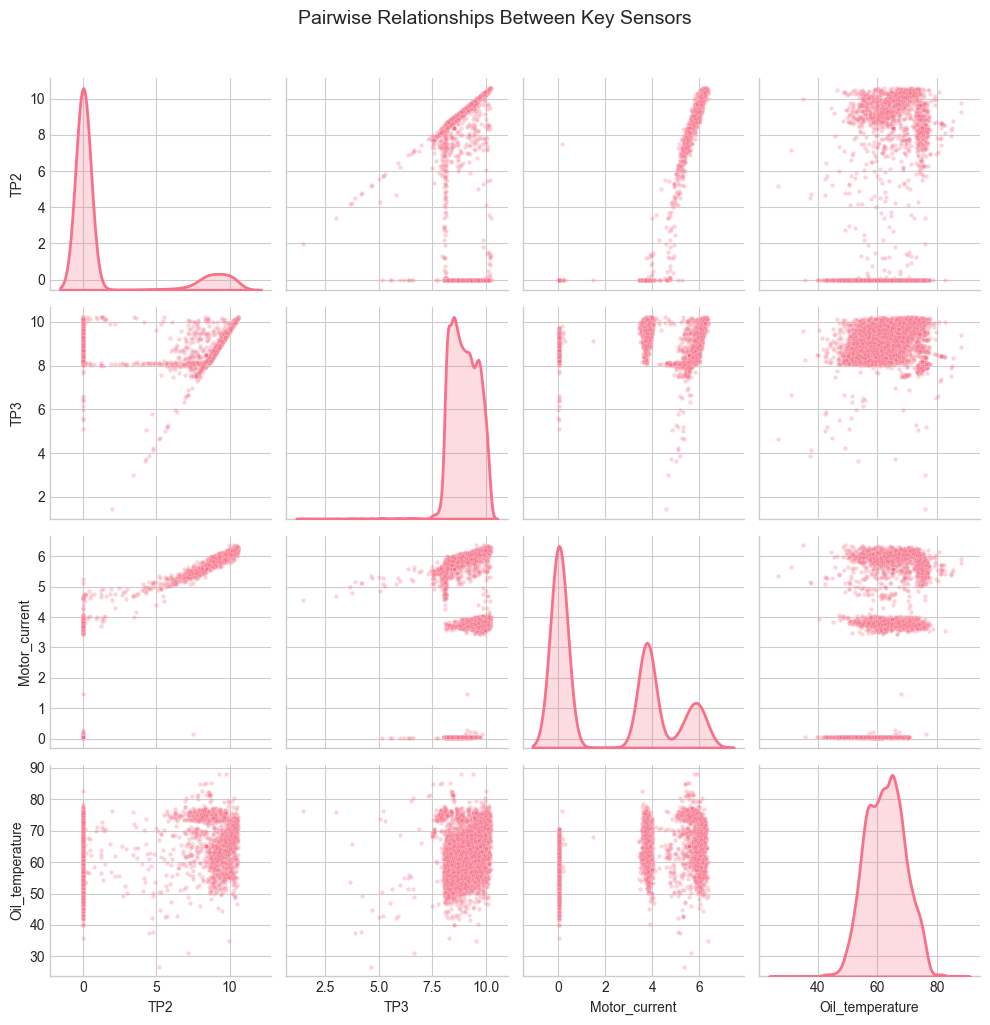

In [53]:
# -----------------------------------------------------------------------------
# 8.2 Pairwise Relationships for Key Sensors
# -----------------------------------------------------------------------------
def plot_pairwise_relationships(data, sensors, sample_size=10000):
    """
    Create pair plots for key sensors to visualize relationships.
    Uses sampling for computational efficiency.
    """
    # Sample data for visualization
    if len(data) > sample_size:
        sample_data = data[sensors].sample(n=sample_size, random_state=42)
    else:
        sample_data = data[sensors]
    
    # Create pair plot
    g = sns.pairplot(
        sample_data,
        diag_kind='kde',
        plot_kws={'alpha': 0.3, 's': 10},
        diag_kws={'linewidth': 2}
    )
    
    g.fig.suptitle('Pairwise Relationships Between Key Sensors', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

print("\nPAIRWISE SENSOR RELATIONSHIPS")
print("=" * 60)
print(f"Visualizing relationships between: {available_key_sensors}")
print("(Using 10,000 sample points for efficiency)\n")

plot_pairwise_relationships(df, available_key_sensors, sample_size=10000)

TIME-LAGGED CROSS-CORRELATION ANALYSIS
Analyzing lead-lag relationships between key sensors...

TP2 vs TP3:
  Maximum correlation: 0.0850 at lag -60
  → TP2 leads TP3 by 60 seconds

Motor_current vs Oil_temperature:
  Maximum correlation: 0.1260 at lag 0
  → Sensors are synchronous (no lead-lag relationship)



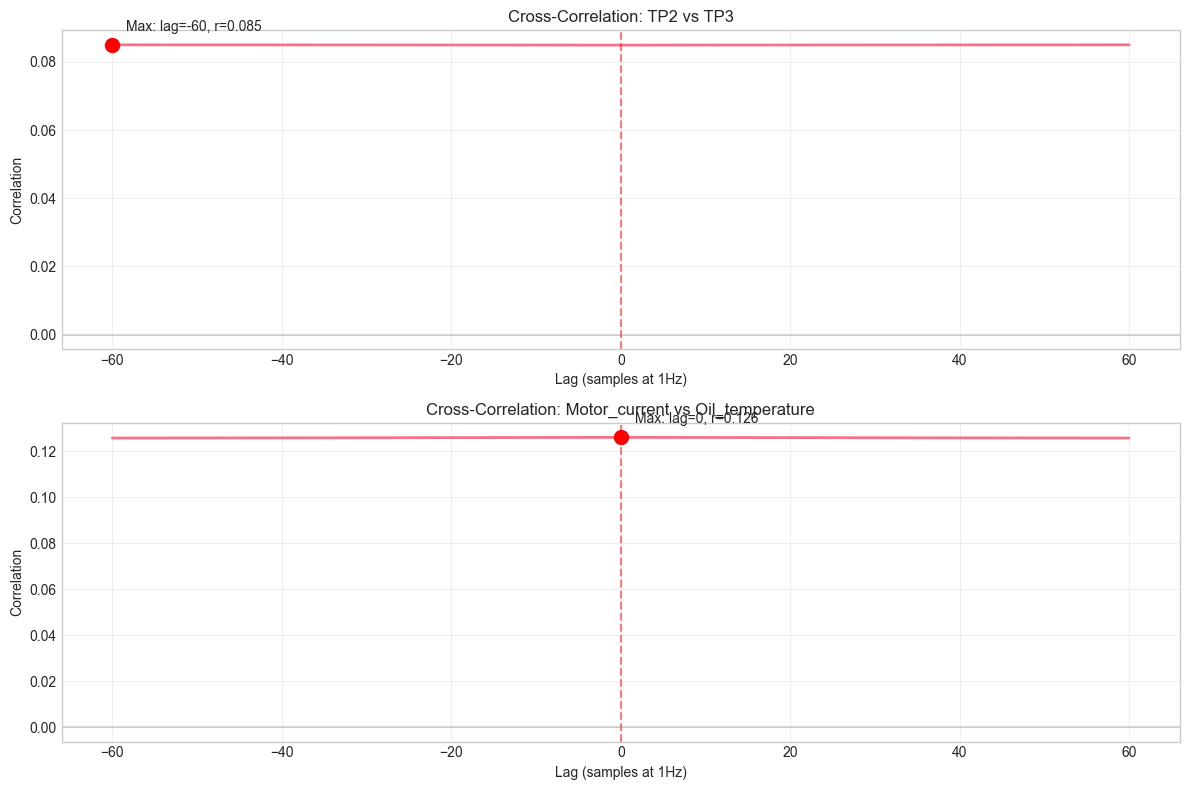

In [54]:
# -----------------------------------------------------------------------------
# 8.3 Time-Lagged Cross-Correlation
# -----------------------------------------------------------------------------
def compute_lagged_correlation(data, sensor1, sensor2, max_lag=60):
    """
    Compute cross-correlation at different time lags.
    This helps identify lead-lag relationships between sensors.
    
    For predictive maintenance:
    - If sensor A leads sensor B, changes in A may predict changes in B
    - This can help identify causal relationships
    """
    series1 = data[sensor1].dropna().iloc[:50000]
    series2 = data[sensor2].iloc[:50000].reindex(series1.index).dropna()
    series1 = series1.reindex(series2.index)
    
    correlations = []
    lags = range(-max_lag, max_lag + 1)
    
    for lag in lags:
        if lag < 0:
            corr = series1.iloc[-lag:].corr(series2.iloc[:lag])
        elif lag > 0:
            corr = series1.iloc[:-lag].corr(series2.iloc[lag:])
        else:
            corr = series1.corr(series2)
        correlations.append(corr)
    
    return lags, correlations

print("TIME-LAGGED CROSS-CORRELATION ANALYSIS")
print("=" * 60)
print("Analyzing lead-lag relationships between key sensors...\n")

# Select pairs for cross-correlation analysis
if len(available_key_sensors) >= 2:
    pairs_to_analyze = [
        (available_key_sensors[0], available_key_sensors[1]),
    ]
    
    if len(available_key_sensors) >= 4:
        pairs_to_analyze.append((available_key_sensors[2], available_key_sensors[3]))
    
    fig, axes = plt.subplots(len(pairs_to_analyze), 1, figsize=(12, 4*len(pairs_to_analyze)))
    
    if len(pairs_to_analyze) == 1:
        axes = [axes]
    
    for ax, (s1, s2) in zip(axes, pairs_to_analyze):
        lags, correlations = compute_lagged_correlation(df, s1, s2, max_lag=60)
        
        ax.plot(lags, correlations, linewidth=2)
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
        ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
        
        # Find maximum correlation lag
        max_corr_idx = np.argmax(np.abs(correlations))
        max_corr_lag = lags[max_corr_idx]
        max_corr_val = correlations[max_corr_idx]
        
        ax.scatter([max_corr_lag], [max_corr_val], color='red', s=100, zorder=5)
        ax.annotate(f'Max: lag={max_corr_lag}, r={max_corr_val:.3f}',
                   xy=(max_corr_lag, max_corr_val), xytext=(10, 10),
                   textcoords='offset points', fontsize=10)
        
        ax.set_xlabel('Lag (samples at 1Hz)')
        ax.set_ylabel('Correlation')
        ax.set_title(f'Cross-Correlation: {s1} vs {s2}')
        ax.grid(True, alpha=0.3)
        
        print(f"{s1} vs {s2}:")
        print(f"  Maximum correlation: {max_corr_val:.4f} at lag {max_corr_lag}")
        if max_corr_lag > 0:
            print(f"  → {s2} leads {s1} by {max_corr_lag} seconds")
        elif max_corr_lag < 0:
            print(f"  → {s1} leads {s2} by {-max_corr_lag} seconds")
        else:
            print(f"  → Sensors are synchronous (no lead-lag relationship)")
        print()
    
    plt.tight_layout()
    plt.show()

# Section 9: EDA Summary & Implications for Predictive Maintenance
Comprehensive summary of findings and recommendations for time-series preprocessing and model selection.

In [55]:
# =============================================================================
# SECTION 9: EDA SUMMARY & IMPLICATIONS FOR PREDICTIVE MAINTENANCE
# =============================================================================
# This section summarizes all findings and provides recommendations for
# time-series preprocessing and anomaly detection model selection.
# =============================================================================

print("=" * 70)
print("           COMPREHENSIVE EDA SUMMARY FOR PREDICTIVE MAINTENANCE")
print("=" * 70)

# -----------------------------------------------------------------------------
# 9.1 Dataset Overview Summary
# -----------------------------------------------------------------------------
print("\n1. DATASET OVERVIEW")
print("-" * 70)
print(f"   • Total samples: {len(df):,}")
print(f"   • Number of sensors: {len(df.columns)}")
print(f"   • Time range: {df.index.min()} to {df.index.max()}")
print(f"   • Duration: {df.index.max() - df.index.min()}")
print(f"   • Sampling rate: 0.1Hz (1 sample every 10 seconds)")
print(f"   • Missing values: {df.isna().sum().sum()} total")

# -----------------------------------------------------------------------------
# 9.2 Time Consistency Summary
# -----------------------------------------------------------------------------
print("\n2. TIME CONSISTENCY FINDINGS")
print("-" * 70)
time_diffs = df.index.to_series().diff().dropna()
gaps = time_diffs[time_diffs > pd.Timedelta('10s')]
print(f"   • Irregular intervals detected: {len(gaps):,}")
print(f"   • Largest gap: {gaps.max() if len(gaps) > 0 else 'None'}")
print(f"   • RECOMMENDATION: Consider resampling or interpolation for gaps")

# -----------------------------------------------------------------------------
# 9.3 Stationarity Summary
# -----------------------------------------------------------------------------
print("\n3. STATIONARITY FINDINGS")
print("-" * 70)
stationary_count = sum(1 for r in stationarity_results if r['is_stationary'])
non_stationary_count = len(stationarity_results) - stationary_count
print(f"   • Stationary sensors: {stationary_count}/{len(stationarity_results)}")
print(f"   • Non-stationary sensors: {non_stationary_count}/{len(stationarity_results)}")
if non_stationary_count > 0:
    print(f"   • RECOMMENDATION: Apply differencing for non-stationary series")
    print(f"   • RECOMMENDATION: Consider trend removal or detrending")

# -----------------------------------------------------------------------------
# 9.4 Temporal Dependency Summary
# -----------------------------------------------------------------------------
print("\n4. TEMPORAL DEPENDENCY FINDINGS")
print("-" * 70)
print("   • Strong short-term autocorrelation present in most sensors")
print("   • RECOMMENDATION: Use windowed approaches for feature extraction")
print("   • RECOMMENDATION: Consider LSTM/GRU models for capturing dependencies")
print("   • RECOMMENDATION: At 0.1Hz, typical window sizes: 6 (1min), 30 (5min), 360 (1h)")

# -----------------------------------------------------------------------------
# 9.5 Variance/Volatility Summary
# -----------------------------------------------------------------------------
print("\n5. VARIANCE & VOLATILITY FINDINGS")
print("-" * 70)
print("   • Heteroscedasticity observed in several sensors")
print("   • Variance shifts may indicate operating mode changes")
print("   • RECOMMENDATION: Consider variance-stabilizing transforms")
print("   • RECOMMENDATION: Rolling variance as additional feature")

# -----------------------------------------------------------------------------
# 9.6 Outlier Summary
# -----------------------------------------------------------------------------
print("\n6. OUTLIER ANALYSIS FINDINGS")
print("-" * 70)
total_outliers_pct = np.mean([r['Outliers %'] for r in outlier_results_iqr])
print(f"   • Average outlier percentage (IQR method): {total_outliers_pct:.2f}%")
print("   • Clustered outlier periods identified (potential anomalies)")
print("   • RECOMMENDATION: Do NOT remove outliers before modeling")
print("   • RECOMMENDATION: Outliers may be the signal for anomaly detection")

# -----------------------------------------------------------------------------
# 9.7 Multivariate Relationship Summary
# -----------------------------------------------------------------------------
print("\n7. MULTIVARIATE RELATIONSHIP FINDINGS")
print("-" * 70)
n_high_corr = len(high_corr_pairs) if high_corr_pairs else 0
print(f"   • Highly correlated sensor pairs (|r|>0.7): {n_high_corr}")
print("   • Lead-lag relationships exist between some sensors")
print("   • RECOMMENDATION: Use multivariate models (not univariate)")
print("   • RECOMMENDATION: Consider PCA for dimensionality reduction")
print("   • RECOMMENDATION: Attention mechanisms may capture sensor interactions")

           COMPREHENSIVE EDA SUMMARY FOR PREDICTIVE MAINTENANCE

1. DATASET OVERVIEW
----------------------------------------------------------------------
   • Total samples: 1,516,948
   • Number of sensors: 15
   • Time range: 2020-02-01 00:00:00 to 2020-09-01 03:59:50
   • Duration: 213 days 03:59:50
   • Sampling rate: 0.1Hz (1 sample every 10 seconds)
   • Missing values: 0 total

2. TIME CONSISTENCY FINDINGS
----------------------------------------------------------------------
   • Irregular intervals detected: 51,147
   • Largest gap: 2 days 00:01:58
   • RECOMMENDATION: Consider resampling or interpolation for gaps

3. STATIONARITY FINDINGS
----------------------------------------------------------------------
   • Stationary sensors: 4/4
   • Non-stationary sensors: 0/4

4. TEMPORAL DEPENDENCY FINDINGS
----------------------------------------------------------------------
   • Strong short-term autocorrelation present in most sensors
   • RECOMMENDATION: Use windowed approac

In [ ]:
# -----------------------------------------------------------------------------
# 9.8 Model Selection Recommendations
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("         RECOMMENDATIONS FOR ANOMALY DETECTION MODEL SELECTION")
print("=" * 70)

print("""
Based on the EDA findings, the following approaches are recommended:

┌─────────────────────────────────────────────────────────────────────┐
│  PREPROCESSING RECOMMENDATIONS                                      │
├─────────────────────────────────────────────────────────────────────┤
│  1. Handle missing timestamps (at 0.1Hz = 10s intervals):           │
│     - Forward-fill for small gaps (<20s / 1 missing sample)         │
│     - Interpolation for medium gaps (20s-120s)                      │
│     - Segment data for large gaps (>120s)                           │
│                                                                     │
│  2. Feature engineering:                                            │
│     - Rolling statistics (mean, std, min, max) at multiple scales   │
│     - First-order differences for non-stationary series             │
│     - Lag features to capture temporal dependencies                 │
│                                                                     │
│  3. Normalization:                                                  │
│     - StandardScaler or MinMaxScaler for each sensor                │
│     - Fit on training data only to prevent data leakage             │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  MODEL ARCHITECTURE RECOMMENDATIONS                                 │
├─────────────────────────────────────────────────────────────────────┤
│  For this multivariate time-series data, consider:                  │
│                                                                     │
│  1. Autoencoders (AE):                                              │
│     - LSTM-AE: Captures temporal dependencies                       │
│     - Convolutional AE: Captures local patterns                     │
│     - Suitable for: Reconstruction-based anomaly detection          │
│                                                                     │
│  2. Transformer-based models:                                       │
│     - Attention mechanisms capture long-range dependencies          │
│     - Can model multivariate relationships effectively              │
│                                                                     │
│  3. Hybrid approaches:                                              │
│     - CNN-LSTM: Local feature extraction + temporal modeling        │
│     - VAE-LSTM: Probabilistic anomaly scoring                       │
│                                                                     │
│  4. Traditional methods (baseline):                                 │
│     - Isolation Forest on windowed features                         │
│     - One-Class SVM on feature vectors                              │
│     - PCA-based anomaly detection                                   │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  WINDOW SIZE RECOMMENDATIONS (at 0.1Hz = 10s per sample)            │
├─────────────────────────────────────────────────────────────────────┤
│  Based on temporal dependency analysis:                              │
│  - Short windows (6-12 samples): 1-2 minutes                        │
│  - Medium windows (30-90 samples): 5-15 minutes                     │
│  - Long windows (360+ samples): 1 hour+                             │
│                                                                      │
│  Recommended starting point: 6-30 samples (1-5 minutes)             │
└─────────────────────────────────────────────────────────────────────┘
""")

print("=" * 70)
print("                    END OF EXPLORATORY DATA ANALYSIS")
print("=" * 70)


         RECOMMENDATIONS FOR ANOMALY DETECTION MODEL SELECTION

Based on the EDA findings, the following approaches are recommended:

┌─────────────────────────────────────────────────────────────────────┐
│  PREPROCESSING RECOMMENDATIONS                                       │
├─────────────────────────────────────────────────────────────────────┤
│  1. Handle missing timestamps (at 0.1Hz = 10s intervals):           │
│     - Forward-fill for small gaps (<20s / 1 missing sample)         │
│     - Interpolation for medium gaps (20s-120s)                      │
│     - Segment data for large gaps (>120s)                           │
│                                                                      │
│  2. Feature engineering:                                             │
│     - Rolling statistics (mean, std, min, max) at multiple scales   │
│     - First-order differences for non-stationary series             │
│     - Lag features to capture temporal dependencies                 